In [1]:
# LLM Hallucination & Fact-Checking Benchmarker
#
# This project evaluates whether an LLM response is supported
# by a given reference document.
#
# Main areas:
# - Claim extraction
# - Semantic similarity
# - Grounding evaluation
# - Hallucination detection
# - Error analysis
# - Evaluation metrics

In [2]:
!pip install -q pandas numpy scikit-learn sentence-transformers spacy

In [3]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import spacy

from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

In [4]:
print("Libraries loaded successfully.")

Libraries loaded successfully.


In [5]:
!python -m spacy download en_core_web_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 97.3 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [6]:
nlp = spacy.load("en_core_web_sm")

print("spaCy model loaded.")

spaCy model loaded.


In [7]:
model = SentenceTransformer("all-MiniLM-L6-v2")

print("Embedding model loaded.")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model loaded.


In [8]:
response = """
The Eiffel Tower is located in Paris.
It was completed in 1889.
It is one of the most famous landmarks in France.
"""

doc = nlp(response)

claims = []

for sentence in doc.sents:
    text = sentence.text.strip()

    if text:
        claims.append(text)

print("Extracted claims:")

for number, claim in enumerate(claims, start=1):
    print(f"{number}. {claim}")

Extracted claims:
1. The Eiffel Tower is located in Paris.
2. It was completed in 1889.
3. It is one of the most famous landmarks in France.


In [9]:
source = "The Eiffel Tower is located in Paris."

claim_1 = "The Eiffel Tower is in Paris."
claim_2 = "The Eiffel Tower is located in London."

In [10]:
source_embedding = model.encode([source])

claim_embeddings = model.encode([
    claim_1,
    claim_2
])

In [11]:
scores = cosine_similarity(
    claim_embeddings,
    source_embedding
).flatten()

print("Claim 1 similarity:", round(scores[0], 3))
print("Claim 2 similarity:", round(scores[1], 3))

Claim 1 similarity: 0.986
Claim 2 similarity: 0.86


In [12]:
folders = [
    "data",
    "src",
    "tests"
]

for folder in folders:
    Path(folder).mkdir(exist_ok=True)

print("Project folders created.")

Project folders created.


In [13]:
for folder in folders:
    print(folder)

data
src
tests


In [14]:
dataset = [
    {
        "test_id": "TC001",
        "domain": "science",
        "source": "Water freezes at 0 degrees Celsius at standard atmospheric pressure.",
        "question": "At what temperature does water freeze?",
        "response": "Water freezes at 0 degrees Celsius at standard atmospheric pressure.",
        "label": "grounded"
    },
    {
        "test_id": "TC002",
        "domain": "science",
        "source": "Water freezes at 0 degrees Celsius at standard atmospheric pressure.",
        "question": "At what temperature does water freeze?",
        "response": "Water freezes at 10 degrees Celsius at standard atmospheric pressure.",
        "label": "contradiction"
    },
    {
        "test_id": "TC003",
        "domain": "science",
        "source": "Water freezes at 0 degrees Celsius at standard atmospheric pressure.",
        "question": "At what temperature does water freeze?",
        "response": "Water freezes at 0 degrees Celsius and was discovered by Albert Einstein.",
        "label": "partial"
    },
    {
        "test_id": "TC004",
        "domain": "science",
        "source": "Water freezes at 0 degrees Celsius at standard atmospheric pressure.",
        "question": "At what temperature does water freeze?",
        "response": "The Moon is approximately 384,400 kilometers from Earth.",
        "label": "irrelevant"
    },
    {
        "test_id": "TC005",
        "domain": "science",
        "source": "Water freezes at 0 degrees Celsius at standard atmospheric pressure.",
        "question": "At what temperature does water freeze?",
        "response": "Water freezes at 0 degrees Celsius, and the freezing point is never affected by pressure.",
        "label": "unsupported"
    }
]

print(f"Created {len(dataset)} test cases.")

Created 5 test cases.


In [15]:
df = pd.DataFrame(dataset)

df

,test_id,domain,source,question,response,label
0,TC001,science,Water freezes at 0 degrees Celsius at standard...,At what temperature does water freeze?,Water freezes at 0 degrees Celsius at standard...,grounded
1,TC002,science,Water freezes at 0 degrees Celsius at standard...,At what temperature does water freeze?,Water freezes at 10 degrees Celsius at standar...,contradiction
2,TC003,science,Water freezes at 0 degrees Celsius at standard...,At what temperature does water freeze?,Water freezes at 0 degrees Celsius and was dis...,partial
3,TC004,science,Water freezes at 0 degrees Celsius at standard...,At what temperature does water freeze?,"The Moon is approximately 384,400 kilometers f...",irrelevant
4,TC005,science,Water freezes at 0 degrees Celsius at standard...,At what temperature does water freeze?,"Water freezes at 0 degrees Celsius, and the fr...",unsupported


In [16]:
required_columns = [
    "test_id",
    "domain",
    "source",
    "question",
    "response",
    "label"
]

for column in required_columns:
    if column not in df.columns:
        raise ValueError(f"Missing column: {column}")

allowed_labels = {
    "grounded",
    "unsupported",
    "partial",
    "contradiction",
    "irrelevant"
}

invalid_labels = set(df["label"]) - allowed_labels

if invalid_labels:
    raise ValueError(f"Invalid labels found: {invalid_labels}")

print("Dataset validation passed.")

Dataset validation passed.


In [17]:
print(df["label"].value_counts())

label
grounded         1
contradiction    1
partial          1
irrelevant       1
unsupported      1
Name: count, dtype: int64


In [18]:
dataset_path = Path("data/evaluation_dataset.json")

with open(dataset_path, "w", encoding="utf-8") as file:
    json.dump(dataset, file, indent=2)

print(f"Dataset saved to: {dataset_path}")

Dataset saved to: data/evaluation_dataset.json


In [19]:
benchmark_data = [
    {
        "test_id": "TC001",
        "domain": "science",
        "difficulty": "easy",
        "source": (
            "Water freezes at 0 degrees Celsius at standard atmospheric pressure."
        ),
        "question": "At what temperature does water freeze?",
        "response": (
            "Water freezes at 0 degrees Celsius at standard atmospheric pressure."
        ),
        "claims": [
            "Water freezes at 0 degrees Celsius at standard atmospheric pressure."
        ],
        "evidence": [
            "Water freezes at 0 degrees Celsius at standard atmospheric pressure."
        ],
        "label": "grounded",
        "error_type": "none"
    },

    {
        "test_id": "TC002",
        "domain": "science",
        "difficulty": "easy",
        "source": (
            "Water freezes at 0 degrees Celsius at standard atmospheric pressure."
        ),
        "question": "At what temperature does water freeze?",
        "response": (
            "Water freezes at 10 degrees Celsius at standard atmospheric pressure."
        ),
        "claims": [
            "Water freezes at 10 degrees Celsius at standard atmospheric pressure."
        ],
        "evidence": [
            "Water freezes at 0 degrees Celsius at standard atmospheric pressure."
        ],
        "label": "contradiction",
        "error_type": "contradiction"
    },

    {
        "test_id": "TC003",
        "domain": "science",
        "difficulty": "medium",
        "source": (
            "Water freezes at 0 degrees Celsius at standard atmospheric pressure."
        ),
        "question": "What is known about the freezing point of water?",
        "response": (
            "Water freezes at 0 degrees Celsius and was discovered by Albert Einstein."
        ),
        "claims": [
            "Water freezes at 0 degrees Celsius.",
            "Water was discovered by Albert Einstein."
        ],
        "evidence": [
            "Water freezes at 0 degrees Celsius at standard atmospheric pressure."
        ],
        "label": "partial",
        "error_type": "unsupported_claim"
    },

    {
        "test_id": "TC004",
        "domain": "science",
        "difficulty": "medium",
        "source": (
            "Water freezes at 0 degrees Celsius at standard atmospheric pressure."
        ),
        "question": "What is the freezing point of water?",
        "response": (
            "Water freezes at 0 degrees Celsius, and its freezing point "
            "is never affected by pressure."
        ),
        "claims": [
            "Water freezes at 0 degrees Celsius.",
            "The freezing point of water is never affected by pressure."
        ],
        "evidence": [
            "Water freezes at 0 degrees Celsius at standard atmospheric pressure."
        ],
        "label": "partial",
        "error_type": "unsupported_claim"
    },

    {
        "test_id": "TC005",
        "domain": "science",
        "difficulty": "easy",
        "source": (
            "Water freezes at 0 degrees Celsius at standard atmospheric pressure."
        ),
        "question": "At what temperature does water freeze?",
        "response": (
            "The Moon is approximately 384,400 kilometers from Earth."
        ),
        "claims": [
            "The Moon is approximately 384,400 kilometers from Earth."
        ],
        "evidence": [],
        "label": "irrelevant",
        "error_type": "irrelevant_response"
    },

    {
        "test_id": "TC006",
        "domain": "history",
        "difficulty": "easy",
        "source": (
            "The Apollo 11 mission landed the first humans on the Moon "
            "in July 1969."
        ),
        "question": "Which mission first landed humans on the Moon?",
        "response": (
            "Apollo 11 was the first mission to land humans on the Moon."
        ),
        "claims": [
            "Apollo 11 was the first mission to land humans on the Moon."
        ],
        "evidence": [
            "The Apollo 11 mission landed the first humans on the Moon in July 1969."
        ],
        "label": "grounded",
        "error_type": "none"
    },

    {
        "test_id": "TC007",
        "domain": "history",
        "difficulty": "easy",
        "source": (
            "The Apollo 11 mission landed the first humans on the Moon "
            "in July 1969."
        ),
        "question": "When did Apollo 11 land humans on the Moon?",
        "response": (
            "Apollo 11 landed humans on the Moon in July 1972."
        ),
        "claims": [
            "Apollo 11 landed humans on the Moon in July 1972."
        ],
        "evidence": [
            "The Apollo 11 mission landed the first humans on the Moon in July 1969."
        ],
        "label": "contradiction",
        "error_type": "contradiction"
    },

    {
        "test_id": "TC008",
        "domain": "technology",
        "difficulty": "easy",
        "source": (
            "Python is a high-level programming language known for "
            "its readable syntax."
        ),
        "question": "What type of programming language is Python?",
        "response": (
            "Python is a high-level programming language with readable syntax."
        ),
        "claims": [
            "Python is a high-level programming language.",
            "Python is known for readable syntax."
        ],
        "evidence": [
            "Python is a high-level programming language known for its readable syntax."
        ],
        "label": "grounded",
        "error_type": "none"
    },

    {
        "test_id": "TC009",
        "domain": "technology",
        "difficulty": "medium",
        "source": (
            "Python is a high-level programming language known for "
            "its readable syntax."
        ),
        "question": "Describe Python.",
        "response": (
            "Python is a high-level programming language with readable syntax "
            "and was created by Microsoft."
        ),
        "claims": [
            "Python is a high-level programming language.",
            "Python has readable syntax.",
            "Python was created by Microsoft."
        ],
        "evidence": [
            "Python is a high-level programming language known for its readable syntax."
        ],
        "label": "partial",
        "error_type": "unsupported_claim"
    },

    {
        "test_id": "TC010",
        "domain": "geography",
        "difficulty": "easy",
        "source": (
            "The Pacific Ocean is the largest ocean on Earth."
        ),
        "question": "Which is the largest ocean on Earth?",
        "response": (
            "The Pacific Ocean is the largest ocean on Earth."
        ),
        "claims": [
            "The Pacific Ocean is the largest ocean on Earth."
        ],
        "evidence": [
            "The Pacific Ocean is the largest ocean on Earth."
        ],
        "label": "grounded",
        "error_type": "none"
    }
]

print(f"Created {len(benchmark_data)} benchmark cases.")

Created 10 benchmark cases.


In [20]:
benchmark_df = pd.DataFrame(benchmark_data)

print("Dataset shape:", benchmark_df.shape)

benchmark_df[
    [
        "test_id",
        "domain",
        "difficulty",
        "label",
        "error_type"
    ]
]

Dataset shape: (10, 10)


,test_id,domain,difficulty,label,error_type
0,TC001,science,easy,grounded,none
1,TC002,science,easy,contradiction,contradiction
2,TC003,science,medium,partial,unsupported_claim
3,TC004,science,medium,partial,unsupported_claim
4,TC005,science,easy,irrelevant,irrelevant_response
5,TC006,history,easy,grounded,none
6,TC007,history,easy,contradiction,contradiction
7,TC008,technology,easy,grounded,none
8,TC009,technology,medium,partial,unsupported_claim
9,TC010,geography,easy,grounded,none


In [21]:
print("Label distribution:")
print(benchmark_df["label"].value_counts())

print("\nDomain distribution:")
print(benchmark_df["domain"].value_counts())

print("\nDifficulty distribution:")
print(benchmark_df["difficulty"].value_counts())

Label distribution:
label
grounded         4
partial          3
contradiction    2
irrelevant       1
Name: count, dtype: int64

Domain distribution:
domain
science       5
history       2
technology    2
geography     1
Name: count, dtype: int64

Difficulty distribution:
difficulty
easy      7
medium    3
Name: count, dtype: int64


In [22]:
required_fields = [
    "test_id",
    "domain",
    "difficulty",
    "source",
    "question",
    "response",
    "claims",
    "evidence",
    "label",
    "error_type"
]

allowed_labels = {
    "grounded",
    "unsupported",
    "partial",
    "contradiction",
    "irrelevant"
}

allowed_difficulties = {
    "easy",
    "medium",
    "hard"
}

for item in benchmark_data:

    for field in required_fields:
        if field not in item:
            raise ValueError(
                f"{item.get('test_id', 'Unknown')} is missing {field}"
            )

    if item["label"] not in allowed_labels:
        raise ValueError(
            f"Invalid label in {item['test_id']}: {item['label']}"
        )

    if item["difficulty"] not in allowed_difficulties:
        raise ValueError(
            f"Invalid difficulty in {item['test_id']}"
        )

    if not item["source"].strip():
        raise ValueError(
            f"Empty source in {item['test_id']}"
        )

    if not item["response"].strip():
        raise ValueError(
            f"Empty response in {item['test_id']}"
        )

print("Benchmark validation passed.")

Benchmark validation passed.


In [23]:
dataset_path = Path("data/evaluation_dataset.json")

with open(dataset_path, "w", encoding="utf-8") as file:
    json.dump(
        benchmark_data,
        file,
        indent=2,
        ensure_ascii=False
    )

print(f"Saved dataset to {dataset_path}")

Saved dataset to data/evaluation_dataset.json


In [25]:
segmenter_code = '''
import spacy


nlp = spacy.load("en_core_web_sm")


def extract_claims(text):
    """
    Split an LLM response into individual claims.
    """

    if not text or not text.strip():
        return []

    doc = nlp(text)

    claims = []

    for sentence in doc.sents:
        claim = sentence.text.strip()

        if claim:
            claims.append(claim)

    return claims
'''

with open("src/segmenter.py", "w", encoding="utf-8") as file:
    file.write(segmenter_code)

print("segmenter.py created.")

segmenter.py created.


In [26]:
from src.segmenter import extract_claims

In [27]:
response = """
The Eiffel Tower is located in Paris.
It was completed in 1889.
It attracts millions of visitors every year.
"""

claims = extract_claims(response)

for i, claim in enumerate(claims, start=1):
    print(f"Claim {i}: {claim}")

Claim 1: The Eiffel Tower is located in Paris.
Claim 2: It was completed in 1889.
Claim 3: It attracts millions of visitors every year.


In [28]:
empty_result = extract_claims("")

print("Result:", empty_result)

Result: []


In [29]:
response = (
    "Python is a programming language. "
    "It is known for readable syntax. "
    "It is widely used in data science."
)

claims = extract_claims(response)

print("Number of claims:", len(claims))

for claim in claims:
    print("-", claim)

Number of claims: 3
- Python is a programming language.
- It is known for readable syntax.
- It is widely used in data science.


In [30]:
segmenter_code = '''
import spacy


nlp = spacy.load("en_core_web_sm")


def extract_claims(text):
    """
    Split an LLM response into individual claims.
    """

    if not text or not text.strip():
        return []

    doc = nlp(text)

    claims = []

    for sentence in doc.sents:
        claim = sentence.text.strip()

        if claim:
            claims.append(claim)

    return claims


def count_claims(text):
    """
    Return the number of claims found in a response.
    """

    claims = extract_claims(text)

    return len(claims)
'''

with open("src/segmenter.py", "w", encoding="utf-8") as file:
    file.write(segmenter_code)

print("segmenter.py updated.")

segmenter.py updated.


In [34]:
import importlib
import src.segmenter

importlib.reload(src.segmenter)

from src.segmenter import extract_claims, count_claims

print("segmenter.py reloaded successfully.")

segmenter.py reloaded successfully.


In [35]:
response = """
The Pacific Ocean is the largest ocean on Earth.
It covers a large part of the planet.
"""

claims = extract_claims(response)

print("Number of claims:", count_claims(response))

for i, claim in enumerate(claims, start=1):
    print(f"{i}. {claim}")

Number of claims: 2
1. The Pacific Ocean is the largest ocean on Earth.
2. It covers a large part of the planet.


In [36]:
from src.segmenter import extract_claims

test_case = benchmark_data[2]

print("Test ID:", test_case["test_id"])
print("Original response:")
print(test_case["response"])

print("\nExtracted claims:")

claims = extract_claims(test_case["response"])

for i, claim in enumerate(claims, start=1):
    print(f"{i}. {claim}")

Test ID: TC003
Original response:
Water freezes at 0 degrees Celsius and was discovered by Albert Einstein.

Extracted claims:
1. Water freezes at 0 degrees Celsius and was discovered by Albert Einstein.


In [37]:
evaluator_code = '''
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity


model = SentenceTransformer("all-MiniLM-L6-v2")


def split_source(source):
    """
    Split the reference text into individual evidence sentences.
    """

    sentences = []

    for sentence in source.split("."):
        sentence = sentence.strip()

        if sentence:
            sentences.append(sentence)

    return sentences


def find_best_match(claim, source):
    """
    Find the source sentence that is most similar to a claim.
    """

    source_sentences = split_source(source)

    if not source_sentences:
        return {
            "score": 0.0,
            "evidence": None
        }

    claim_embedding = model.encode([claim])
    source_embeddings = model.encode(source_sentences)

    scores = cosine_similarity(
        claim_embedding,
        source_embeddings
    )[0]

    best_index = scores.argmax()

    return {
        "score": float(scores[best_index]),
        "evidence": source_sentences[best_index]
    }


def evaluate_claim(claim, source, threshold=0.60):
    """
    Evaluate whether a claim is sufficiently supported by the source.
    """

    result = find_best_match(claim, source)

    score = result["score"]

    if score >= threshold:
        label = "grounded"
    else:
        label = "unsupported"

    return {
        "claim": claim,
        "score": round(score, 4),
        "evidence": result["evidence"],
        "label": label
    }
'''

with open("src/evaluator.py", "w", encoding="utf-8") as file:
    file.write(evaluator_code)

print("evaluator.py created successfully.")

evaluator.py created successfully.


In [38]:
from src.evaluator import evaluate_claim, find_best_match

print("Evaluator loaded successfully.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Evaluator loaded successfully.


In [39]:
import importlib
import src.evaluator

importlib.reload(src.evaluator)

from src.evaluator import evaluate_claim, find_best_match

print("Evaluator reloaded successfully.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Evaluator reloaded successfully.


In [40]:
source = "The Pacific Ocean is the largest ocean on Earth."

claim = "The Pacific Ocean is the largest ocean."

In [41]:
result = evaluate_claim(
    claim,
    source,
    threshold=0.60
)

print(result)

{'claim': 'The Pacific Ocean is the largest ocean.', 'score': 0.9587, 'evidence': 'The Pacific Ocean is the largest ocean on Earth', 'label': 'grounded'}


In [42]:
claim = "The Pacific Ocean is located on Mars."

result = evaluate_claim(
    claim,
    source,
    threshold=0.60
)

print(result)

{'claim': 'The Pacific Ocean is located on Mars.', 'score': 0.5824, 'evidence': 'The Pacific Ocean is the largest ocean on Earth', 'label': 'unsupported'}


In [43]:
claims = [
    "The Pacific Ocean is the largest ocean.",
    "The Pacific Ocean is located on Mars."
]

for claim in claims:

    result = evaluate_claim(
        claim,
        source,
        threshold=0.60
    )

    print("\nClaim:", result["claim"])
    print("Score:", result["score"])
    print("Evidence:", result["evidence"])
    print("Label:", result["label"])


Claim: The Pacific Ocean is the largest ocean.
Score: 0.9587
Evidence: The Pacific Ocean is the largest ocean on Earth
Label: grounded

Claim: The Pacific Ocean is located on Mars.
Score: 0.5824
Evidence: The Pacific Ocean is the largest ocean on Earth
Label: unsupported


In [44]:
test_case = benchmark_data[0]

claim = test_case["claims"][0]

result = evaluate_claim(
    claim,
    test_case["source"],
    threshold=0.60
)

print("Test ID:", test_case["test_id"])
print("Claim:", result["claim"])
print("Score:", result["score"])
print("Evidence:", result["evidence"])
print("Predicted label:", result["label"])
print("Human label:", test_case["label"])

Test ID: TC001
Claim: Water freezes at 0 degrees Celsius at standard atmospheric pressure.
Score: 0.9578
Evidence: Water freezes at 0 degrees Celsius at standard atmospheric pressure
Predicted label: grounded
Human label: grounded


In [45]:
reporter_code = '''
import pandas as pd


def calculate_metrics(results):
    """
    Calculate summary metrics from claim-level evaluation results.
    """

    if not results:
        return {
            "total_claims": 0,
            "grounded_claims": 0,
            "unsupported_claims": 0,
            "faithfulness_score": 0.0,
            "average_similarity": 0.0
        }

    result_df = pd.DataFrame(results)

    total_claims = len(result_df)

    grounded_claims = int(
        (result_df["label"] == "grounded").sum()
    )

    unsupported_claims = int(
        (result_df["label"] == "unsupported").sum()
    )

    faithfulness_score = (
        grounded_claims / total_claims
    ) * 100

    average_similarity = result_df["score"].mean()

    return {
        "total_claims": total_claims,
        "grounded_claims": grounded_claims,
        "unsupported_claims": unsupported_claims,
        "faithfulness_score": round(faithfulness_score, 2),
        "average_similarity": round(average_similarity, 4)
    }


def create_report(results):
    """
    Create a readable evaluation report.
    """

    metrics = calculate_metrics(results)

    print("LLM Evaluation Report")
    print("-" * 30)

    print(
        f"Total claims: {metrics['total_claims']}"
    )

    print(
        f"Grounded claims: {metrics['grounded_claims']}"
    )

    print(
        f"Unsupported claims: {metrics['unsupported_claims']}"
    )

    print(
        f"Faithfulness score: "
        f"{metrics['faithfulness_score']}%"
    )

    print(
        f"Average similarity: "
        f"{metrics['average_similarity']}"
    )

    return metrics
'''

with open("src/reporter.py", "w", encoding="utf-8") as file:
    file.write(reporter_code)

print("reporter.py created successfully.")

reporter.py created successfully.


In [46]:
import importlib
import src.reporter

importlib.reload(src.reporter)

from src.reporter import calculate_metrics, create_report

print("Reporter loaded successfully.")

Reporter loaded successfully.


In [47]:
results = [
    {
        "claim": "The Pacific Ocean is the largest ocean.",
        "score": 0.91,
        "evidence": "The Pacific Ocean is the largest ocean on Earth.",
        "label": "grounded"
    },
    {
        "claim": "The Pacific Ocean is located on Mars.",
        "score": 0.22,
        "evidence": "The Pacific Ocean is the largest ocean on Earth.",
        "label": "unsupported"
    },
    {
        "claim": "The Pacific Ocean covers a large area.",
        "score": 0.82,
        "evidence": "The Pacific Ocean is the largest ocean on Earth.",
        "label": "grounded"
    }
]

metrics = calculate_metrics(results)

metrics

{'total_claims': 3,
 'grounded_claims': 2,
 'unsupported_claims': 1,
 'faithfulness_score': 66.67,
 'average_similarity': np.float64(0.65)}

In [48]:
create_report(results)

LLM Evaluation Report
------------------------------
Total claims: 3
Grounded claims: 2
Unsupported claims: 1
Faithfulness score: 66.67%
Average similarity: 0.65


{'total_claims': 3,
 'grounded_claims': 2,
 'unsupported_claims': 1,
 'faithfulness_score': 66.67,
 'average_similarity': np.float64(0.65)}

In [49]:
from src.segmenter import extract_claims
from src.evaluator import evaluate_claim
from src.reporter import create_report


source = """
The Pacific Ocean is the largest ocean on Earth.
It covers a large part of the planet.
"""

response = """
The Pacific Ocean is the largest ocean on Earth.
It was discovered by Christopher Columbus.
It covers a large part of the planet.
"""

claims = extract_claims(response)

results = []

for claim in claims:

    result = evaluate_claim(
        claim,
        source,
        threshold=0.60
    )

    results.append(result)

create_report(results)

LLM Evaluation Report
------------------------------
Total claims: 3
Grounded claims: 2
Unsupported claims: 1
Faithfulness score: 66.67%
Average similarity: 0.7394


{'total_claims': 3,
 'grounded_claims': 2,
 'unsupported_claims': 1,
 'faithfulness_score': 66.67,
 'average_similarity': np.float64(0.7394)}

In [50]:
runner_code = '''
import pandas as pd

from src.segmenter import extract_claims
from src.evaluator import evaluate_claim


def get_binary_label(label):
    """
    Convert the detailed human label into a binary evaluation label.
    """

    if label == "grounded":
        return "grounded"

    return "unsupported"


def evaluate_test_case(test_case, threshold=0.60):
    """
    Evaluate all claims in one benchmark test case.
    """

    claims = extract_claims(test_case["response"])

    results = []

    for claim in claims:
        result = evaluate_claim(
            claim,
            test_case["source"],
            threshold=threshold
        )

        results.append(result)

    return results


def run_benchmark(dataset, threshold=0.60):
    """
    Run the evaluator across the complete benchmark dataset.
    """

    benchmark_results = []

    for test_case in dataset:

        claim_results = evaluate_test_case(
            test_case,
            threshold=threshold
        )

        if not claim_results:
            continue

        predicted_labels = [
            result["label"]
            for result in claim_results
        ]

        grounded_count = predicted_labels.count("grounded")

        if grounded_count == len(predicted_labels):
            predicted_label = "grounded"
        else:
            predicted_label = "unsupported"

        human_label = get_binary_label(
            test_case["label"]
        )

        benchmark_results.append({
            "test_id": test_case["test_id"],
            "human_label": human_label,
            "original_label": test_case["label"],
            "predicted_label": predicted_label,
            "average_score": sum(
                result["score"]
                for result in claim_results
            ) / len(claim_results),
            "claim_count": len(claim_results),
            "correct": predicted_label == human_label
        })

    return pd.DataFrame(benchmark_results)
'''

with open("src/benchmark_runner.py", "w", encoding="utf-8") as file:
    file.write(runner_code)

print("benchmark_runner.py created successfully.")

benchmark_runner.py created successfully.


In [51]:
import importlib
import src.benchmark_runner

importlib.reload(src.benchmark_runner)

from src.benchmark_runner import run_benchmark

print("Benchmark runner loaded successfully.")

Benchmark runner loaded successfully.


In [52]:
benchmark_results = run_benchmark(
    benchmark_data,
    threshold=0.60
)

benchmark_results

,test_id,human_label,original_label,predicted_label,average_score,claim_count,correct
0,TC001,grounded,grounded,grounded,0.9578,1,True
1,TC002,unsupported,contradiction,grounded,0.8902,1,False
2,TC003,unsupported,partial,grounded,0.6208,1,False
3,TC004,unsupported,partial,grounded,0.7594,1,False
4,TC005,unsupported,irrelevant,unsupported,0.1122,1,True
5,TC006,grounded,grounded,grounded,0.8390,1,True
6,TC007,unsupported,contradiction,grounded,0.8322,1,False
7,TC008,grounded,grounded,grounded,0.9669,1,True
8,TC009,unsupported,partial,grounded,0.8691,1,False
9,TC010,grounded,grounded,grounded,0.9906,1,True


In [53]:
accuracy = benchmark_results["correct"].mean()

print(
    f"Benchmark accuracy: {accuracy * 100:.2f}%"
)

Benchmark accuracy: 50.00%


In [54]:
from sklearn.metrics import confusion_matrix

actual = benchmark_results["human_label"]
predicted = benchmark_results["predicted_label"]

matrix = confusion_matrix(
    actual,
    predicted,
    labels=["grounded", "unsupported"]
)

print("Confusion Matrix:")
print(matrix)

Confusion Matrix:
[[4 0]
 [5 1]]


In [55]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

actual_binary = (
    benchmark_results["human_label"] == "unsupported"
)

predicted_binary = (
    benchmark_results["predicted_label"] == "unsupported"
)

precision = precision_score(
    actual_binary,
    predicted_binary,
    zero_division=0
)

recall = recall_score(
    actual_binary,
    predicted_binary,
    zero_division=0
)

f1 = f1_score(
    actual_binary,
    predicted_binary,
    zero_division=0
)

print(f"Precision: {precision:.3f}")
print(f"Recall:    {recall:.3f}")
print(f"F1-score:  {f1:.3f}")

Precision: 1.000
Recall:    0.167
F1-score:  0.286


In [56]:
failures = benchmark_results[
    benchmark_results["correct"] == False
]

print(
    f"Number of incorrect predictions: {len(failures)}"
)

failures[
    [
        "test_id",
        "original_label",
        "predicted_label",
        "average_score"
    ]
]

Number of incorrect predictions: 5


,test_id,original_label,predicted_label,average_score
1,TC002,contradiction,grounded,0.8902
2,TC003,partial,grounded,0.6208
3,TC004,partial,grounded,0.7594
6,TC007,contradiction,grounded,0.8322
8,TC009,partial,grounded,0.8691


In [57]:
thresholds = [
    0.40,
    0.45,
    0.50,
    0.55,
    0.60,
    0.65,
    0.70,
    0.75,
    0.80
]

threshold_results = []

for threshold in thresholds:

    results = run_benchmark(
        benchmark_data,
        threshold=threshold
    )

    actual = (
        results["human_label"] == "unsupported"
    )

    predicted = (
        results["predicted_label"] == "unsupported"
    )

    precision = precision_score(
        actual,
        predicted,
        zero_division=0
    )

    recall = recall_score(
        actual,
        predicted,
        zero_division=0
    )

    f1 = f1_score(
        actual,
        predicted,
        zero_division=0
    )

    threshold_results.append({
        "threshold": threshold,
        "precision": round(precision, 3),
        "recall": round(recall, 3),
        "f1": round(f1, 3)
    })

threshold_df = pd.DataFrame(threshold_results)

threshold_df

,threshold,precision,recall,f1
0,0.40,1.0,0.167,0.286
1,0.45,1.0,0.167,0.286
2,0.50,1.0,0.167,0.286
3,0.55,1.0,0.167,0.286
4,0.60,1.0,0.167,0.286
5,0.65,1.0,0.333,0.500
6,0.70,1.0,0.333,0.500
7,0.75,1.0,0.333,0.500
8,0.80,1.0,0.500,0.667


In [58]:
Path("data").mkdir(exist_ok=True)

benchmark_results.to_csv(
    "data/benchmark_results.csv",
    index=False
)

threshold_df.to_csv(
    "data/threshold_results.csv",
    index=False
)

print("Benchmark results saved.")

Benchmark results saved.


In [59]:
!pip install -q datasets

In [60]:
from datasets import load_dataset

print("Datasets library loaded.")

Datasets library loaded.


In [61]:
halueval = load_dataset(
    "pminervini/HaluEval",
    "qa"
)

print(halueval)

README.md:   0%|          | 0.00/2.88k [00:00<?, ?B/s]

qa/data-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 3.75MB            

qa/data-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating data split:   0%|          | 0/10000 [00:00<?, ? examples/s]

DatasetDict({
    data: Dataset({
        features: ['knowledge', 'question', 'right_answer', 'hallucinated_answer'],
        num_rows: 10000
    })
})


In [62]:
print(halueval)

DatasetDict({
    data: Dataset({
        features: ['knowledge', 'question', 'right_answer', 'hallucinated_answer'],
        num_rows: 10000
    })
})


In [63]:
train_data = halueval["data"]

print("Number of examples:", len(train_data))

Number of examples: 10000


In [64]:
print(train_data[0])

{'knowledge': "Arthur's Magazine (1844–1846) was an American literary periodical published in Philadelphia in the 19th century.First for Women is a woman's magazine published by Bauer Media Group in the USA.", 'question': "Which magazine was started first Arthur's Magazine or First for Women?", 'right_answer': "Arthur's Magazine", 'hallucinated_answer': 'First for Women was started first.'}


In [65]:
normalized_case = {
    "test_id": "HALU_00001",
    "source": "...",
    "question": "...",
    "response": "...",
    "human_label": "hallucinated",
    "domain": "qa",
    "dataset_source": "HaluEval"
}

In [66]:
dataset_info = {
    "project": "LLM Hallucination & Fact-Checking Benchmarker",
    "development_dataset": "Custom controlled benchmark",
    "external_dataset": "HaluEval",
    "evaluation_type": "Hallucination detection",
    "primary_metric": "F1-score",
    "secondary_metrics": [
        "precision",
        "recall",
        "accuracy"
    ]
}

with open(
    "data/dataset_info.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(dataset_info, file, indent=2)

print("Dataset metadata saved.")

Dataset metadata saved.


In [67]:
print(halueval)
print(train_data[0])

DatasetDict({
    data: Dataset({
        features: ['knowledge', 'question', 'right_answer', 'hallucinated_answer'],
        num_rows: 10000
    })
})
{'knowledge': "Arthur's Magazine (1844–1846) was an American literary periodical published in Philadelphia in the 19th century.First for Women is a woman's magazine published by Bauer Media Group in the USA.", 'question': "Which magazine was started first Arthur's Magazine or First for Women?", 'right_answer': "Arthur's Magazine", 'hallucinated_answer': 'First for Women was started first.'}


In [68]:
from datasets import load_dataset

halueval = load_dataset(
    "pminervini/HaluEval",
    "general"
)

print(halueval)

general/data-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.82MB            

general/data-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating data split:   0%|          | 0/4507 [00:00<?, ? examples/s]

DatasetDict({
    data: Dataset({
        features: ['ID', 'user_query', 'chatgpt_response', 'hallucination', 'hallucination_spans'],
        num_rows: 4507
    })
})


In [69]:
general_data = halueval["data"]

print("Number of examples:", len(general_data))

print("\nFirst example:")
print(general_data[0])

Number of examples: 4507

First example:
{'ID': '1', 'user_query': 'Produce a list of common words in the English language.', 'chatgpt_response': 'the, a, and, to, in, that, is, it, of, for, with, was, on, be, by, at, as, but, from, this, have, or, not, are, they, all, an, their, one, has, been, would, who, which, there, if, will, when, can, more, most, no, other, so, about, like, some, into, its, time, up, out, go, could, than, only, these, also, now, him, how, then, make, two, way, been, our, first, thing, may, after, too, any, day, never, same, last, long, even, new, must, here, every, such, own, down, man, people, way, little, much, world, know, good, year, take, come, us, many, again, find, much, just, see, use, get, through, back, well, still, before, without, while, between, life, go, own, off, mean, keep, own, another, put, however, almost, began, interest, show,', 'hallucination': 'no', 'hallucination_spans': []}


In [70]:
halueval_df = general_data.to_pandas()

print(halueval_df.shape)

halueval_df.head()

(4507, 5)


,ID,user_query,chatgpt_response,hallucination,hallucination_spans
0,1,Produce a list of common words in the English ...,"the, a, and, to, in, that, is, it, of, for, wi...",no,[]
1,2,Provide a few examples of homophones.,1. allowed (permitted) and aloud (out loud)\n2...,yes,[6. hear (to perceive sound) and here (in this...
2,3,Create a chart outlining the world's populatio...,"Unfortunately, as an AI language model, I cann...",yes,[| Year | Population (in billions) |\n|------|...
3,4,Design a shape with 10 vertices (corners).,Here is an example of a shape with 10 vertices...,yes,[```\n /\\n / \ \n /____\\n /\ ...
4,5,Automatically generate a 10 by 10 multiplicati...,"Sure, here is a 10 by 10 multiplication table:...",yes,[Incomplete answer]


In [71]:
print(halueval_df.columns.tolist())

['ID', 'user_query', 'chatgpt_response', 'hallucination', 'hallucination_spans']


In [72]:
print(halueval_df["hallucination"].value_counts())

hallucination
no     3692
yes     815
Name: count, dtype: int64


In [73]:
def normalize_halueval_row(row, index):
    """
    Convert one HaluEval example into our project schema.
    """

    label = str(row["hallucination"]).lower().strip()

    if label in {"yes", "true", "1"}:
        human_label = "hallucinated"
    else:
        human_label = "grounded"

    return {
        "test_id": f"HALU_{index:05d}",
        "domain": "general",
        "difficulty": "unknown",
        "source": "",
        "question": row["user_query"],
        "response": row["chatgpt_response"],
        "claims": [],
        "evidence": [],
        "human_label": human_label,
        "hallucination_spans": row["hallucination_spans"],
        "dataset_source": "HaluEval"
    }

In [74]:
sample_size = 500

halueval_sample = halueval_df.head(sample_size)

normalized_halueval = []

for index, row in halueval_sample.iterrows():

    item = normalize_halueval_row(
        row,
        index
    )

    normalized_halueval.append(item)

print(
    "Normalized examples:",
    len(normalized_halueval)
)

Normalized examples: 500


In [75]:
normalized_halueval[0]

{'test_id': 'HALU_00000',
 'domain': 'general',
 'difficulty': 'unknown',
 'source': '',
 'question': 'Produce a list of common words in the English language.',
 'response': 'the, a, and, to, in, that, is, it, of, for, with, was, on, be, by, at, as, but, from, this, have, or, not, are, they, all, an, their, one, has, been, would, who, which, there, if, will, when, can, more, most, no, other, so, about, like, some, into, its, time, up, out, go, could, than, only, these, also, now, him, how, then, make, two, way, been, our, first, thing, may, after, too, any, day, never, same, last, long, even, new, must, here, every, such, own, down, man, people, way, little, much, world, know, good, year, take, come, us, many, again, find, much, just, see, use, get, through, back, well, still, before, without, while, between, life, go, own, off, mean, keep, own, another, put, however, almost, began, interest, show,',
 'claims': [],
 'evidence': [],
 'human_label': 'grounded',
 'hallucination_spans': ar

In [79]:
import json
from pathlib import Path

Path("data/external").mkdir(
    parents=True,
    exist_ok=True
)


def make_json_safe(value):
    """
    Convert NumPy values into normal Python values
    so they can be saved as JSON.
    """

    if hasattr(value, "tolist"):
        return value.tolist()

    if isinstance(value, dict):
        return {
            key: make_json_safe(item)
            for key, item in value.items()
        }

    if isinstance(value, list):
        return [
            make_json_safe(item)
            for item in value
        ]

    return value


safe_halueval = make_json_safe(
    normalized_halueval
)


with open(
    "data/external/halueval_general_500.json",
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        safe_halueval,
        file,
        indent=2,
        ensure_ascii=False
    )

print("HaluEval sample saved successfully.")

HaluEval sample saved successfully.


In [80]:
import json

with open(
    "data/external/halueval_general_500.json",
    "r",
    encoding="utf-8"
) as file:

    saved_data = json.load(file)

print("Examples saved:", len(saved_data))
print("\nFirst example:")
print(saved_data[0])

Examples saved: 500

First example:
{'test_id': 'HALU_00000', 'domain': 'general', 'difficulty': 'unknown', 'source': '', 'question': 'Produce a list of common words in the English language.', 'response': 'the, a, and, to, in, that, is, it, of, for, with, was, on, be, by, at, as, but, from, this, have, or, not, are, they, all, an, their, one, has, been, would, who, which, there, if, will, when, can, more, most, no, other, so, about, like, some, into, its, time, up, out, go, could, than, only, these, also, now, him, how, then, make, two, way, been, our, first, thing, may, after, too, any, day, never, same, last, long, even, new, must, here, every, such, own, down, man, people, way, little, much, world, know, good, year, take, come, us, many, again, find, much, just, see, use, get, through, back, well, still, before, without, while, between, life, go, own, off, mean, keep, own, another, put, however, almost, began, interest, show,', 'claims': [], 'evidence': [], 'human_label': 'grounded'

In [81]:
atomic_claim_code = '''
import spacy


nlp = spacy.load("en_core_web_sm")


def clean_claim(text):
    """
    Clean whitespace and punctuation from a claim.
    """

    return " ".join(text.strip().split()).strip(" ,;")


def split_conjunction(sentence):
    """
    Split simple coordinated clauses into separate claims.

    This is intentionally conservative. It only splits when
    spaCy identifies coordinated predicates or clauses.
    """

    doc = nlp(sentence)

    claims = []

    for token in doc:

        if token.dep_ != "conj":
            continue

        if token.pos_ not in {"VERB", "AUX"}:
            continue

        first_part = []

        for child in token.children:

            if child.dep_ in {
                "nsubj",
                "nsubjpass"
            }:
                first_part.append(child)

        if not first_part:
            continue

        subject = first_part[0].subtree
        subject_text = " ".join(
            word.text for word in subject
        )

        first_claim = (
            f"{subject_text} "
            f"{token.text} "
        )

        for child in token.children:

            if child.dep_ not in {
                "nsubj",
                "nsubjpass"
            }:
                first_claim += child.text + " "

        first_claim = clean_claim(first_claim)

        if first_claim:
            claims.append(first_claim)

    return claims


def extract_atomic_claims(text):
    """
    Extract sentence-level and simple atomic claims.
    """

    if not text or not text.strip():
        return []

    doc = nlp(text)

    atomic_claims = []

    for sentence in doc.sents:

        sentence_text = clean_claim(
            sentence.text
        )

        if not sentence_text:
            continue

        split_claims = split_conjunction(
            sentence_text
        )

        if split_claims:
            atomic_claims.extend(
                split_claims
            )
        else:
            atomic_claims.append(
                sentence_text
            )

    return atomic_claims
'''

with open(
    "src/atomic_claims.py",
    "w",
    encoding="utf-8"
) as file:
    file.write(atomic_claim_code)

print("atomic_claims.py created successfully.")

atomic_claims.py created successfully.


In [82]:
import importlib
import src.atomic_claims

importlib.reload(src.atomic_claims)

from src.atomic_claims import extract_atomic_claims

print("Atomic claim extractor loaded successfully.")

Atomic claim extractor loaded successfully.


In [83]:
text = """
The Pacific Ocean is the largest ocean on Earth.
It covers a large part of the planet.
"""

claims = extract_atomic_claims(text)

for i, claim in enumerate(claims, start=1):
    print(f"{i}. {claim}")

1. The Pacific Ocean is the largest ocean on Earth.
2. It covers a large part of the planet.


In [84]:
text = """
The Pacific Ocean is the largest ocean and covers a large part of the planet.
"""

claims = extract_atomic_claims(text)

for i, claim in enumerate(claims, start=1):
    print(f"{i}. {claim}")

1. The Pacific Ocean is the largest ocean and covers a large part of the planet.


In [85]:
test_code = '''
from src.atomic_claims import extract_atomic_claims


def test_empty_text():
    assert extract_atomic_claims("") == []


def test_single_sentence():
    text = "The Earth revolves around the Sun."

    claims = extract_atomic_claims(text)

    assert len(claims) == 1


def test_multiple_sentences():
    text = (
        "The Earth revolves around the Sun. "
        "The Moon revolves around the Earth."
    )

    claims = extract_atomic_claims(text)

    assert len(claims) == 2


def test_claims_are_not_empty():
    text = (
        "Python is widely used in data science. "
        "SQL is used for querying databases."
    )

    claims = extract_atomic_claims(text)

    assert all(
        claim.strip()
        for claim in claims
    )


print("All basic atomic claim tests passed.")
'''

with open(
    "tests/test_atomic_claims.py",
    "w",
    encoding="utf-8"
) as file:
    file.write(test_code)

print("Test file created.")

Test file created.


In [86]:
!python tests/test_atomic_claims.py

Traceback (most recent call last):
  File "/content/tests/test_atomic_claims.py", line 2, in <module>
    from src.atomic_claims import extract_atomic_claims
ModuleNotFoundError: No module named 'src'


In [87]:
from src.segmenter import extract_claims
from src.atomic_claims import extract_atomic_claims


response = """
Water freezes at 0 degrees Celsius and boils at 100 degrees Celsius.
The Pacific Ocean is the largest ocean on Earth.
"""

old_claims = extract_claims(response)
new_claims = extract_atomic_claims(response)

print("OLD SEGMENTER")
print("-" * 30)

for claim in old_claims:
    print("-", claim)


print("\nATOMIC CLAIM EXTRACTOR")
print("-" * 30)

for claim in new_claims:
    print("-", claim)

OLD SEGMENTER
------------------------------
- Water freezes at 0 degrees Celsius and boils at 100 degrees Celsius.
- The Pacific Ocean is the largest ocean on Earth.

ATOMIC CLAIM EXTRACTOR
------------------------------
- Water freezes at 0 degrees Celsius and boils at 100 degrees Celsius.
- The Pacific Ocean is the largest ocean on Earth.


In [88]:
def extract_claim_records(text):
    """
    Return atomic claims with stable IDs.
    """

    claims = extract_atomic_claims(text)

    records = []

    for index, claim in enumerate(
        claims,
        start=1
    ):
        records.append({
            "claim_id": index,
            "claim": claim
        })

    return records

In [89]:
from pathlib import Path

path = Path("src/atomic_claims.py")

current_code = path.read_text(
    encoding="utf-8"
)

current_code += '''

def extract_claim_records(text):
    """
    Return atomic claims with stable IDs.
    """

    claims = extract_atomic_claims(text)

    records = []

    for index, claim in enumerate(
        claims,
        start=1
    ):
        records.append({
            "claim_id": index,
            "claim": claim
        })

    return records
'''

path.write_text(
    current_code,
    encoding="utf-8"
)

print("Claim record function added.")

Claim record function added.


In [90]:
response = """
Python was created by Guido van Rossum.
It was first released in 1991.
"""

records = extract_claim_records(response)

records

[{'claim_id': 1, 'claim': 'Python was created by Guido van Rossum.'},
 {'claim_id': 2, 'claim': 'It was first released in 1991.'}]

In [91]:
!pip install -q -U sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 740.6/740.6 kB 9.3 MB/s eta 0:00:00


In [92]:
contradiction_code = '''
from sentence_transformers import CrossEncoder


MODEL_NAME = "cross-encoder/nli-deberta-v3-base"

model = CrossEncoder(MODEL_NAME)


LABELS = {
    0: "contradiction",
    1: "entailment",
    2: "neutral"
}


def predict_relation(claim, evidence):
    """
    Predict the relationship between a claim and its evidence.

    Returns:
        contradiction
        entailment
        neutral
    """

    if not claim or not evidence:
        return {
            "label": "neutral",
            "scores": {}
        }

    scores = model.predict(
        [(evidence, claim)]
    )[0]

    probabilities = {
        LABELS[index]: float(score)
        for index, score in enumerate(scores)
    }

    predicted_label = max(
        probabilities,
        key=probabilities.get
    )

    return {
        "label": predicted_label,
        "scores": probabilities
    }
'''

with open(
    "src/contradiction.py",
    "w",
    encoding="utf-8"
) as file:
    file.write(contradiction_code)

print("contradiction.py created successfully.")

contradiction.py created successfully.


In [93]:
import importlib
import src.contradiction

importlib.reload(src.contradiction)

from src.contradiction import predict_relation

print("Contradiction detector loaded successfully.")

config.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  738MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.35k [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/8.66M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

Contradiction detector loaded successfully.


In [94]:
evidence = "The company was founded in 2010."

claim = "The company was founded in 2010."

result = predict_relation(
    claim,
    evidence
)

print(result)

{'label': 'entailment', 'scores': {'contradiction': -4.663210868835449, 'entailment': 4.456355571746826, 'neutral': -1.1753662824630737}}


In [95]:
evidence = "The company was founded in 2010."

claim = "The company was founded in 2020."

result = predict_relation(
    claim,
    evidence
)

print(result)

{'label': 'contradiction', 'scores': {'contradiction': 6.576650142669678, 'entailment': -3.683239459991455, 'neutral': -2.5797832012176514}}


In [96]:
evidence = "The company was founded in 2010."

claim = "The company has offices in Mumbai."

result = predict_relation(
    claim,
    evidence
)

print(result)

{'label': 'neutral', 'scores': {'contradiction': -1.6603795289993286, 'entailment': -3.6015665531158447, 'neutral': 5.659402847290039}}


In [97]:
from pathlib import Path
import shutil

shutil.copy(
    "src/evaluator.py",
    "src/evaluator_backup.py"
)

print("Backup created.")

Backup created.


In [98]:
evaluator_code = '''
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

from src.contradiction import predict_relation


model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)


def split_source(source):
    """
    Split reference text into evidence sentences.
    """

    sentences = []

    for sentence in source.split("."):

        sentence = sentence.strip()

        if sentence:
            sentences.append(sentence)

    return sentences


def find_best_match(claim, source):
    """
    Find the strongest semantic evidence for a claim.
    """

    source_sentences = split_source(source)

    if not source_sentences:
        return {
            "score": 0.0,
            "evidence": None
        }

    claim_embedding = model.encode(
        [claim]
    )

    source_embeddings = model.encode(
        source_sentences
    )

    scores = cosine_similarity(
        claim_embedding,
        source_embeddings
    )[0]

    best_index = scores.argmax()

    return {
        "score": float(
            scores[best_index]
        ),
        "evidence": source_sentences[
            best_index
        ]
    }


def evaluate_claim(
    claim,
    source,
    threshold=0.60
):
    """
    Evaluate a claim using semantic similarity
    and contradiction detection.
    """

    match = find_best_match(
        claim,
        source
    )

    similarity_score = match["score"]
    evidence = match["evidence"]

    if evidence is None:
        return {
            "claim": claim,
            "score": 0.0,
            "evidence": None,
            "relation": "neutral",
            "label": "unsupported"
        }

    relation = predict_relation(
        claim,
        evidence
    )

    relation_label = relation["label"]

    if relation_label == "contradiction":
        final_label = "contradiction"

    elif (
        relation_label == "entailment"
        and similarity_score >= threshold
    ):
        final_label = "grounded"

    elif similarity_score >= threshold:
        final_label = "supported_candidate"

    else:
        final_label = "unsupported"

    return {
        "claim": claim,
        "score": round(
            similarity_score,
            4
        ),
        "evidence": evidence,
        "relation": relation_label,
        "label": final_label
    }
'''

with open(
    "src/evaluator.py",
    "w",
    encoding="utf-8"
) as file:
    file.write(evaluator_code)

print("evaluator.py updated successfully.")

evaluator.py updated successfully.


In [99]:
import importlib
import src.evaluator

importlib.reload(src.evaluator)

from src.evaluator import evaluate_claim

print("Updated evaluator loaded.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Updated evaluator loaded.


In [100]:
source = """
The company was founded in 2010.
"""

claim = "The company was founded in 2020."

result = evaluate_claim(
    claim,
    source,
    threshold=0.60
)

print("Claim:", result["claim"])
print("Evidence:", result["evidence"])
print("Similarity:", result["score"])
print("Relation:", result["relation"])
print("Final label:", result["label"])

Claim: The company was founded in 2020.
Evidence: The company was founded in 2010
Similarity: 0.7254
Relation: contradiction
Final label: contradiction


In [101]:
source = """
The company was founded in 2010.
"""

claim = "The company was founded in 2010."

result = evaluate_claim(
    claim,
    source,
    threshold=0.60
)

print(result)

{'claim': 'The company was founded in 2010.', 'score': 0.9899, 'evidence': 'The company was founded in 2010', 'relation': 'entailment', 'label': 'grounded'}


In [102]:
source = """
The company was founded in 2010.
"""

claim = "The company has offices in Pune."

result = evaluate_claim(
    claim,
    source,
    threshold=0.60
)

print(result)

{'claim': 'The company has offices in Pune.', 'score': 0.3613, 'evidence': 'The company was founded in 2010', 'relation': 'neutral', 'label': 'unsupported'}


In [103]:
source = """
The Pacific Ocean is the largest ocean on Earth.
"""

response = """
The Pacific Ocean is the largest ocean on Earth.
It was discovered by Christopher Columbus.
"""

claims = extract_atomic_claims(response)

for claim in claims:

    result = evaluate_claim(
        claim,
        source,
        threshold=0.60
    )

    print("\nClaim:", claim)
    print("Similarity:", result["score"])
    print("Evidence:", result["evidence"])
    print("Relation:", result["relation"])
    print("Final:", result["label"])


Claim: The Pacific Ocean is the largest ocean on Earth.
Similarity: 0.9906
Evidence: The Pacific Ocean is the largest ocean on Earth
Relation: entailment
Final: grounded

Claim: It was discovered by Christopher Columbus.
Similarity: 0.2178
Evidence: The Pacific Ocean is the largest ocean on Earth
Relation: neutral
Final: unsupported


In [104]:
reporter_code = '''
def classify_error(result):
    """
    Convert the evaluator output into a clear error category.
    """

    label = result.get("label")
    relation = result.get("relation")
    score = result.get("score", 0.0)

    if label == "grounded":
        return {
            "error_type": "None",
            "severity": "None",
            "reason": "The claim is supported by the available evidence."
        }

    if label == "contradiction":
        return {
            "error_type": "Factual Contradiction",
            "severity": "High",
            "reason": (
                "The claim conflicts with the strongest "
                "available evidence."
            )
        }

    if label == "unsupported":
        return {
            "error_type": "Unsupported Claim",
            "severity": "Medium",
            "reason": (
                "No sufficiently strong evidence was found "
                "to support the claim."
            )
        }

    if label == "supported_candidate":
        return {
            "error_type": "Needs Review",
            "severity": "Low",
            "reason": (
                "The claim is semantically similar to the evidence, "
                "but the NLI model did not confirm entailment."
            )
        }

    return {
        "error_type": "Unknown",
        "severity": "Review",
        "reason": "The evaluation result requires manual inspection."
    }


def build_audit_record(result, claim_id=None):
    """
    Create one human-readable audit record for a claim.
    """

    error = classify_error(result)

    return {
        "claim_id": claim_id,
        "claim": result.get("claim"),
        "evidence": result.get("evidence"),
        "similarity_score": result.get("score"),
        "nli_relation": result.get("relation"),
        "verdict": result.get("label"),
        "error_type": error["error_type"],
        "severity": error["severity"],
        "reason": error["reason"]
    }


def build_audit_report(results):
    """
    Convert a list of evaluator results into
    claim-level audit records.
    """

    report = []

    for index, result in enumerate(
        results,
        start=1
    ):
        record = build_audit_record(
            result,
            claim_id=index
        )

        report.append(record)

    return report


def calculate_summary(audit_report):
    """
    Calculate high-level evaluation metrics.
    """

    total_claims = len(audit_report)

    grounded = sum(
        1
        for item in audit_report
        if item["verdict"] == "grounded"
    )

    contradictions = sum(
        1
        for item in audit_report
        if item["verdict"] == "contradiction"
    )

    unsupported = sum(
        1
        for item in audit_report
        if item["verdict"] == "unsupported"
    )

    review = sum(
        1
        for item in audit_report
        if item["verdict"] == "supported_candidate"
    )

    if total_claims:
        faithfulness = (
            grounded / total_claims
        ) * 100
    else:
        faithfulness = 0.0

    return {
        "total_claims": total_claims,
        "grounded_claims": grounded,
        "contradictions": contradictions,
        "unsupported_claims": unsupported,
        "needs_review": review,
        "faithfulness_score": round(
            faithfulness,
            2
        )
    }
'''

with open(
    "src/reporter.py",
    "w",
    encoding="utf-8"
) as file:
    file.write(reporter_code)

print("reporter.py updated successfully.")

reporter.py updated successfully.


In [105]:
import importlib
import src.reporter

importlib.reload(src.reporter)

from src.reporter import (
    classify_error,
    build_audit_record,
    build_audit_report,
    calculate_summary
)

print("Reporter loaded successfully.")

Reporter loaded successfully.


In [106]:
source = """
The company was founded in 2010.
"""

claim = "The company was founded in 2020."

result = evaluate_claim(
    claim,
    source,
    threshold=0.60
)

print(result)

{'claim': 'The company was founded in 2020.', 'score': 0.7254, 'evidence': 'The company was founded in 2010', 'relation': 'contradiction', 'label': 'contradiction'}


In [107]:
audit = build_audit_record(
    result,
    claim_id=1
)

audit

{'claim_id': 1,
 'claim': 'The company was founded in 2020.',
 'evidence': 'The company was founded in 2010',
 'similarity_score': 0.7254,
 'nli_relation': 'contradiction',
 'verdict': 'contradiction',
 'error_type': 'Factual Contradiction',
 'severity': 'High',
 'reason': 'The claim conflicts with the strongest available evidence.'}

In [108]:
from src.atomic_claims import extract_atomic_claims
from src.evaluator import evaluate_claim
from src.reporter import (
    build_audit_report,
    calculate_summary
)


source = """
The Pacific Ocean is the largest ocean on Earth.
The Pacific Ocean covers approximately 165 million square kilometers.
The Pacific Ocean is located between Asia, Australia and the Americas.
"""


response = """
The Pacific Ocean is the largest ocean on Earth.
It covers approximately 165 million square kilometers.
The Pacific Ocean was discovered by Christopher Columbus.
"""


claims = extract_atomic_claims(response)

print("Extracted claims:")

for index, claim in enumerate(
    claims,
    start=1
):
    print(f"{index}. {claim}")

Extracted claims:
1. The Pacific Ocean is the largest ocean on Earth.
2. It covers approximately 165 million square kilometers.
3. The Pacific Ocean was discovered by Christopher Columbus.


In [109]:
results = []

for claim in claims:

    result = evaluate_claim(
        claim,
        source,
        threshold=0.60
    )

    results.append(result)


print("Claims evaluated:", len(results))

Claims evaluated: 3


In [110]:
for result in results:

    print("\nClaim:", result["claim"])
    print("Evidence:", result["evidence"])
    print("Similarity:", result["score"])
    print("Relation:", result["relation"])
    print("Verdict:", result["label"])


Claim: The Pacific Ocean is the largest ocean on Earth.
Evidence: The Pacific Ocean is the largest ocean on Earth
Similarity: 0.9906
Relation: entailment
Verdict: grounded

Claim: It covers approximately 165 million square kilometers.
Evidence: The Pacific Ocean covers approximately 165 million square kilometers
Similarity: 0.7321
Relation: neutral
Verdict: supported_candidate

Claim: The Pacific Ocean was discovered by Christopher Columbus.
Evidence: The Pacific Ocean is located between Asia, Australia and the Americas
Similarity: 0.6003
Relation: neutral
Verdict: supported_candidate


In [111]:
audit_report = build_audit_report(
    results
)

for record in audit_report:

    print("\n" + "=" * 60)

    print("Claim ID:", record["claim_id"])
    print("Claim:", record["claim"])
    print("Evidence:", record["evidence"])
    print("Similarity:", record["similarity_score"])
    print("NLI:", record["nli_relation"])
    print("Verdict:", record["verdict"])
    print("Error Type:", record["error_type"])
    print("Severity:", record["severity"])
    print("Reason:", record["reason"])


Claim ID: 1
Claim: The Pacific Ocean is the largest ocean on Earth.
Evidence: The Pacific Ocean is the largest ocean on Earth
Similarity: 0.9906
NLI: entailment
Verdict: grounded
Error Type: None
Severity: None
Reason: The claim is supported by the available evidence.

Claim ID: 2
Claim: It covers approximately 165 million square kilometers.
Evidence: The Pacific Ocean covers approximately 165 million square kilometers
Similarity: 0.7321
NLI: neutral
Verdict: supported_candidate
Error Type: Needs Review
Severity: Low
Reason: The claim is semantically similar to the evidence, but the NLI model did not confirm entailment.

Claim ID: 3
Claim: The Pacific Ocean was discovered by Christopher Columbus.
Evidence: The Pacific Ocean is located between Asia, Australia and the Americas
Similarity: 0.6003
NLI: neutral
Verdict: supported_candidate
Error Type: Needs Review
Severity: Low
Reason: The claim is semantically similar to the evidence, but the NLI model did not confirm entailment.


In [112]:
summary = calculate_summary(
    audit_report
)

print(summary)

{'total_claims': 3, 'grounded_claims': 1, 'contradictions': 0, 'unsupported_claims': 0, 'needs_review': 2, 'faithfulness_score': 33.33}


In [113]:
import pandas as pd

audit_df = pd.DataFrame(
    audit_report
)

audit_df

,claim_id,claim,evidence,similarity_score,nli_relation,verdict,error_type,severity,reason
0,1,The Pacific Ocean is the largest ocean on Earth.,The Pacific Ocean is the largest ocean on Earth,0.9906,entailment,grounded,None,None,The claim is supported by the available evidence.
1,2,It covers approximately 165 million square kil...,The Pacific Ocean covers approximately 165 mil...,0.7321,neutral,supported_candidate,Needs Review,Low,The claim is semantically similar to the evide...
2,3,The Pacific Ocean was discovered by Christophe...,"The Pacific Ocean is located between Asia, Aus...",0.6003,neutral,supported_candidate,Needs Review,Low,The claim is semantically similar to the evide...


In [114]:
from pathlib import Path

Path("data/results").mkdir(
    parents=True,
    exist_ok=True
)

In [115]:
audit_df.to_csv(
    "data/results/claim_audit.csv",
    index=False
)

print("Claim audit saved successfully.")

Claim audit saved successfully.


In [116]:
import json

with open(
    "data/results/evaluation_summary.json",
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        summary,
        file,
        indent=2
    )

print("Evaluation summary saved successfully.")

Evaluation summary saved successfully.


In [117]:
print(audit_df)

   claim_id                                              claim  \
0         1   The Pacific Ocean is the largest ocean on Earth.   
1         2  It covers approximately 165 million square kil...   
2         3  The Pacific Ocean was discovered by Christophe...   

                                            evidence  similarity_score  \
0    The Pacific Ocean is the largest ocean on Earth            0.9906   
1  The Pacific Ocean covers approximately 165 mil...            0.7321   
2  The Pacific Ocean is located between Asia, Aus...            0.6003   

  nli_relation              verdict    error_type severity  \
0   entailment             grounded          None     None   
1      neutral  supported_candidate  Needs Review      Low   
2      neutral  supported_candidate  Needs Review      Low   

                                              reason  
0  The claim is supported by the available evidence.  
1  The claim is semantically similar to the evide...  
2  The claim is semantic

In [118]:
print(summary)

{'total_claims': 3, 'grounded_claims': 1, 'contradictions': 0, 'unsupported_claims': 0, 'needs_review': 2, 'faithfulness_score': 33.33}


In [119]:
print(
    "Saved:",
    "data/results/claim_audit.csv"
)

Saved: data/results/claim_audit.csv


In [120]:
benchmark_runner_code = '''
import json
from pathlib import Path

import pandas as pd

from src.atomic_claims import extract_atomic_claims
from src.evaluator import evaluate_claim
from src.reporter import build_audit_record


def load_dataset(file_path):
    """
    Load benchmark examples from a JSON file.
    """

    path = Path(file_path)

    if not path.exists():
        raise FileNotFoundError(
            f"Dataset not found: {file_path}"
        )

    with open(
        path,
        "r",
        encoding="utf-8"
    ) as file:

        data = json.load(file)

    if not isinstance(data, list):
        raise ValueError(
            "Benchmark dataset must contain a list of examples."
        )

    return data


def evaluate_test_case(
    test_case,
    threshold=0.60
):
    """
    Evaluate all claims in one test case.
    """

    source = test_case.get(
        "source",
        ""
    )

    response = test_case.get(
        "response",
        ""
    )

    test_id = test_case.get(
        "test_id",
        "unknown"
    )

    claims = extract_atomic_claims(
        response
    )

    records = []

    for claim_number, claim in enumerate(
        claims,
        start=1
    ):

        result = evaluate_claim(
            claim,
            source,
            threshold=threshold
        )

        audit_record = build_audit_record(
            result,
            claim_id=f"{test_id}_{claim_number}"
        )

        audit_record["test_id"] = test_id

        records.append(
            audit_record
        )

    return records


def run_benchmark(
    dataset_path,
    threshold=0.60
):
    """
    Run the evaluator across the complete benchmark dataset.
    """

    dataset = load_dataset(
        dataset_path
    )

    all_records = []

    print(
        f"Running benchmark on {len(dataset)} test cases..."
    )

    for index, test_case in enumerate(
        dataset,
        start=1
    ):

        records = evaluate_test_case(
            test_case,
            threshold=threshold
        )

        all_records.extend(records)

        if index % 10 == 0:
            print(
                f"Processed {index}/{len(dataset)} cases"
            )

    return pd.DataFrame(
        all_records
    )


def save_benchmark_results(
    dataframe,
    output_path
):
    """
    Save benchmark results as CSV.
    """

    output = Path(output_path)

    output.parent.mkdir(
        parents=True,
        exist_ok=True
    )

    dataframe.to_csv(
        output,
        index=False
    )

    print(
        f"Results saved to: {output}"
    )
'''

with open(
    "src/benchmark_runner.py",
    "w",
    encoding="utf-8"
) as file:
    file.write(benchmark_runner_code)

print("benchmark_runner.py created successfully.")

benchmark_runner.py created successfully.


In [121]:
import importlib
import src.benchmark_runner

importlib.reload(
    src.benchmark_runner
)

from src.benchmark_runner import (
    load_dataset,
    evaluate_test_case,
    run_benchmark,
    save_benchmark_results
)

print("Benchmark runner loaded successfully.")

Benchmark runner loaded successfully.


In [122]:
dataset = load_dataset(
    "data/evaluation_dataset.json"
)

print(
    "Number of test cases:",
    len(dataset)
)

print("\nFirst test case:")
print(dataset[0])

Number of test cases: 10

First test case:
{'test_id': 'TC001', 'domain': 'science', 'difficulty': 'easy', 'source': 'Water freezes at 0 degrees Celsius at standard atmospheric pressure.', 'question': 'At what temperature does water freeze?', 'response': 'Water freezes at 0 degrees Celsius at standard atmospheric pressure.', 'claims': ['Water freezes at 0 degrees Celsius at standard atmospheric pressure.'], 'evidence': ['Water freezes at 0 degrees Celsius at standard atmospheric pressure.'], 'label': 'grounded', 'error_type': 'none'}


In [123]:
single_result = evaluate_test_case(
    dataset[0],
    threshold=0.60
)

print(
    "Claims evaluated:",
    len(single_result)
)

for record in single_result:

    print("\n" + "-" * 60)

    print("Claim:", record["claim"])
    print("Evidence:", record["evidence"])
    print("Similarity:", record["similarity_score"])
    print("NLI:", record["nli_relation"])
    print("Verdict:", record["verdict"])
    print("Error:", record["error_type"])

Claims evaluated: 1

------------------------------------------------------------
Claim: Water freezes at 0 degrees Celsius at standard atmospheric pressure.
Evidence: Water freezes at 0 degrees Celsius at standard atmospheric pressure
Similarity: 0.9578
NLI: entailment
Verdict: grounded
Error: None


In [124]:
small_dataset = dataset[:10]

small_results = []

for test_case in small_dataset:

    records = evaluate_test_case(
        test_case,
        threshold=0.60
    )

    small_results.extend(
        records
    )

print(
    "Total claims evaluated:",
    len(small_results)
)

Total claims evaluated: 10


In [125]:
small_results_df = pd.DataFrame(
    small_results
)

small_results_df.head()

,claim_id,claim,evidence,similarity_score,nli_relation,verdict,error_type,severity,reason,test_id
0,TC001_1,Water freezes at 0 degrees Celsius at standard...,Water freezes at 0 degrees Celsius at standard...,0.9578,entailment,grounded,None,None,The claim is supported by the available evidence.,TC001
1,TC002_1,Water freezes at 10 degrees Celsius at standar...,Water freezes at 0 degrees Celsius at standard...,0.8902,contradiction,contradiction,Factual Contradiction,High,The claim conflicts with the strongest availab...,TC002
2,TC003_1,Water freezes at 0 degrees Celsius and was dis...,Water freezes at 0 degrees Celsius at standard...,0.6208,neutral,supported_candidate,Needs Review,Low,The claim is semantically similar to the evide...,TC003
3,TC004_1,its freezing point affected is never by .,Water freezes at 0 degrees Celsius at standard...,0.5145,contradiction,contradiction,Factual Contradiction,High,The claim conflicts with the strongest availab...,TC004
4,TC005_1,"The Moon is approximately 384,400 kilometers f...",Water freezes at 0 degrees Celsius at standard...,0.1122,contradiction,contradiction,Factual Contradiction,High,The claim conflicts with the strongest availab...,TC005


In [126]:
print(
    small_results_df["verdict"].value_counts()
)

verdict
grounded               4
contradiction          4
supported_candidate    2
Name: count, dtype: int64


In [127]:
benchmark_results = run_benchmark(
    "data/evaluation_dataset.json",
    threshold=0.60
)

print(
    "\nTotal claims evaluated:",
    len(benchmark_results)
)

Running benchmark on 10 test cases...
Processed 10/10 cases

Total claims evaluated: 10


In [128]:
save_benchmark_results(
    benchmark_results,
    "data/results/benchmark_results.csv"
)

Results saved to: data/results/benchmark_results.csv


In [129]:
benchmark_results.head(10)

,claim_id,claim,evidence,similarity_score,nli_relation,verdict,error_type,severity,reason,test_id
0,TC001_1,Water freezes at 0 degrees Celsius at standard...,Water freezes at 0 degrees Celsius at standard...,0.9578,entailment,grounded,None,None,The claim is supported by the available evidence.,TC001
1,TC002_1,Water freezes at 10 degrees Celsius at standar...,Water freezes at 0 degrees Celsius at standard...,0.8902,contradiction,contradiction,Factual Contradiction,High,The claim conflicts with the strongest availab...,TC002
2,TC003_1,Water freezes at 0 degrees Celsius and was dis...,Water freezes at 0 degrees Celsius at standard...,0.6208,neutral,supported_candidate,Needs Review,Low,The claim is semantically similar to the evide...,TC003
3,TC004_1,its freezing point affected is never by .,Water freezes at 0 degrees Celsius at standard...,0.5145,contradiction,contradiction,Factual Contradiction,High,The claim conflicts with the strongest availab...,TC004
4,TC005_1,"The Moon is approximately 384,400 kilometers f...",Water freezes at 0 degrees Celsius at standard...,0.1122,contradiction,contradiction,Factual Contradiction,High,The claim conflicts with the strongest availab...,TC005
5,TC006_1,Apollo 11 was the first mission to land humans...,The Apollo 11 mission landed the first humans ...,0.8390,entailment,grounded,None,None,The claim is supported by the available evidence.,TC006
6,TC007_1,Apollo 11 landed humans on the Moon in July 1972.,The Apollo 11 mission landed the first humans ...,0.8322,contradiction,contradiction,Factual Contradiction,High,The claim conflicts with the strongest availab...,TC007
7,TC008_1,Python is a high-level programming language wi...,Python is a high-level programming language kn...,0.9669,entailment,grounded,None,None,The claim is supported by the available evidence.,TC008
8,TC009_1,Python is a high-level programming language wi...,Python is a high-level programming language kn...,0.8691,neutral,supported_candidate,Needs Review,Low,The claim is semantically similar to the evide...,TC009
9,TC010_1,The Pacific Ocean is the largest ocean on Earth.,The Pacific Ocean is the largest ocean on Earth,0.9906,entailment,grounded,None,None,The claim is supported by the available evidence.,TC010


In [130]:
benchmark_results.head(10)

,claim_id,claim,evidence,similarity_score,nli_relation,verdict,error_type,severity,reason,test_id
0,TC001_1,Water freezes at 0 degrees Celsius at standard...,Water freezes at 0 degrees Celsius at standard...,0.9578,entailment,grounded,None,None,The claim is supported by the available evidence.,TC001
1,TC002_1,Water freezes at 10 degrees Celsius at standar...,Water freezes at 0 degrees Celsius at standard...,0.8902,contradiction,contradiction,Factual Contradiction,High,The claim conflicts with the strongest availab...,TC002
2,TC003_1,Water freezes at 0 degrees Celsius and was dis...,Water freezes at 0 degrees Celsius at standard...,0.6208,neutral,supported_candidate,Needs Review,Low,The claim is semantically similar to the evide...,TC003
3,TC004_1,its freezing point affected is never by .,Water freezes at 0 degrees Celsius at standard...,0.5145,contradiction,contradiction,Factual Contradiction,High,The claim conflicts with the strongest availab...,TC004
4,TC005_1,"The Moon is approximately 384,400 kilometers f...",Water freezes at 0 degrees Celsius at standard...,0.1122,contradiction,contradiction,Factual Contradiction,High,The claim conflicts with the strongest availab...,TC005
5,TC006_1,Apollo 11 was the first mission to land humans...,The Apollo 11 mission landed the first humans ...,0.8390,entailment,grounded,None,None,The claim is supported by the available evidence.,TC006
6,TC007_1,Apollo 11 landed humans on the Moon in July 1972.,The Apollo 11 mission landed the first humans ...,0.8322,contradiction,contradiction,Factual Contradiction,High,The claim conflicts with the strongest availab...,TC007
7,TC008_1,Python is a high-level programming language wi...,Python is a high-level programming language kn...,0.9669,entailment,grounded,None,None,The claim is supported by the available evidence.,TC008
8,TC009_1,Python is a high-level programming language wi...,Python is a high-level programming language kn...,0.8691,neutral,supported_candidate,Needs Review,Low,The claim is semantically similar to the evide...,TC009
9,TC010_1,The Pacific Ocean is the largest ocean on Earth.,The Pacific Ocean is the largest ocean on Earth,0.9906,entailment,grounded,None,None,The claim is supported by the available evidence.,TC010


In [131]:
benchmark_results.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   claim_id          10 non-null     object 
 1   claim             10 non-null     object 
 2   evidence          10 non-null     object 
 3   similarity_score  10 non-null     float64
 4   nli_relation      10 non-null     object 
 5   verdict           10 non-null     object 
 6   error_type        10 non-null     object 
 7   severity          10 non-null     object 
 8   reason            10 non-null     object 
 9   test_id           10 non-null     object 
dtypes: float64(1), object(9)
memory usage: 932.0+ bytes


In [132]:
verdict_counts = (
    benchmark_results["verdict"]
    .value_counts()
)

print(verdict_counts)

verdict
grounded               4
contradiction          4
supported_candidate    2
Name: count, dtype: int64


In [133]:
verdict_percentages = (
    benchmark_results["verdict"]
    .value_counts(
        normalize=True
    )
    .mul(100)
    .round(2)
)

print(verdict_percentages)

verdict
grounded               40.0
contradiction          40.0
supported_candidate    20.0
Name: proportion, dtype: float64


In [134]:
from pathlib import Path

reporter_path = Path(
    "src/reporter.py"
)

reporter_code = reporter_path.read_text(
    encoding="utf-8"
)

reporter_code += '''

def calculate_benchmark_metrics(dataframe):
    """
    Calculate high-level metrics for a benchmark run.
    """

    total_claims = len(dataframe)

    grounded = (
        dataframe["verdict"] == "grounded"
    ).sum()

    contradictions = (
        dataframe["verdict"] == "contradiction"
    ).sum()

    unsupported = (
        dataframe["verdict"] == "unsupported"
    ).sum()

    review = (
        dataframe["verdict"]
        == "supported_candidate"
    ).sum()

    if total_claims:
        faithfulness = (
            grounded / total_claims
        ) * 100
    else:
        faithfulness = 0.0

    contradiction_rate = (
        contradictions / total_claims * 100
        if total_claims
        else 0.0
    )

    unsupported_rate = (
        unsupported / total_claims * 100
        if total_claims
        else 0.0
    )

    return {
        "total_claims": int(total_claims),
        "grounded_claims": int(grounded),
        "contradictions": int(contradictions),
        "unsupported_claims": int(unsupported),
        "needs_review": int(review),
        "faithfulness_score": round(
            faithfulness,
            2
        ),
        "contradiction_rate": round(
            contradiction_rate,
            2
        ),
        "unsupported_rate": round(
            unsupported_rate,
            2
        )
    }
'''

reporter_path.write_text(
    reporter_code,
    encoding="utf-8"
)

print("Benchmark metrics added.")

Benchmark metrics added.


In [135]:
import importlib
import src.reporter

importlib.reload(
    src.reporter
)

from src.reporter import (
    calculate_benchmark_metrics
)

In [136]:
metrics = calculate_benchmark_metrics(
    benchmark_results
)

metrics

{'total_claims': 10,
 'grounded_claims': 4,
 'contradictions': 4,
 'unsupported_claims': 0,
 'needs_review': 2,
 'faithfulness_score': np.float64(40.0),
 'contradiction_rate': np.float64(40.0),
 'unsupported_rate': np.float64(0.0)}

In [137]:
import json

with open(
    "data/results/benchmark_metrics.json",
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        metrics,
        file,
        indent=2
    )

print("Benchmark metrics saved.")

Benchmark metrics saved.


In [138]:
print(dataset[0].keys())

dict_keys(['test_id', 'domain', 'difficulty', 'source', 'question', 'response', 'claims', 'evidence', 'label', 'error_type'])


In [139]:
for item in dataset[:5]:
    print(item)
    print("-" * 60)

{'test_id': 'TC001', 'domain': 'science', 'difficulty': 'easy', 'source': 'Water freezes at 0 degrees Celsius at standard atmospheric pressure.', 'question': 'At what temperature does water freeze?', 'response': 'Water freezes at 0 degrees Celsius at standard atmospheric pressure.', 'claims': ['Water freezes at 0 degrees Celsius at standard atmospheric pressure.'], 'evidence': ['Water freezes at 0 degrees Celsius at standard atmospheric pressure.'], 'label': 'grounded', 'error_type': 'none'}
------------------------------------------------------------
{'test_id': 'TC002', 'domain': 'science', 'difficulty': 'easy', 'source': 'Water freezes at 0 degrees Celsius at standard atmospheric pressure.', 'question': 'At what temperature does water freeze?', 'response': 'Water freezes at 10 degrees Celsius at standard atmospheric pressure.', 'claims': ['Water freezes at 10 degrees Celsius at standard atmospheric pressure.'], 'evidence': ['Water freezes at 0 degrees Celsius at standard atmospheric

In [140]:
metrics_code = '''
def calculate_binary_metrics(
    y_true,
    y_pred
):
    """
    Calculate binary classification metrics.

    Positive class:
        hallucinated

    Negative class:
        grounded
    """

    tp = 0
    fp = 0
    fn = 0
    tn = 0

    for actual, predicted in zip(
        y_true,
        y_pred
    ):

        if actual == "hallucinated" and predicted == "hallucinated":
            tp += 1

        elif actual == "grounded" and predicted == "hallucinated":
            fp += 1

        elif actual == "hallucinated" and predicted == "grounded":
            fn += 1

        elif actual == "grounded" and predicted == "grounded":
            tn += 1

    precision = (
        tp / (tp + fp)
        if (tp + fp)
        else 0.0
    )

    recall = (
        tp / (tp + fn)
        if (tp + fn)
        else 0.0
    )

    if precision + recall:
        f1 = (
            2 * precision * recall
            / (precision + recall)
        )
    else:
        f1 = 0.0

    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1": round(f1, 4)
    }
'''

with open(
    "src/metrics.py",
    "w",
    encoding="utf-8"
) as file:
    file.write(metrics_code)

print("metrics.py created successfully.")

metrics.py created successfully.


In [141]:
import importlib
import src.metrics

importlib.reload(src.metrics)

from src.metrics import calculate_binary_metrics

print("Metrics module loaded.")

Metrics module loaded.


In [142]:
calibration_code = '''
from src.evaluator import evaluate_claim
from src.atomic_claims import extract_atomic_claims
from src.metrics import calculate_binary_metrics


def predict_test_case(
    test_case,
    threshold
):
    """
    Produce a binary hallucination prediction
    for one test case.

    A response is considered hallucinated if
    at least one extracted claim is classified
    as unsupported or contradictory.
    """

    source = test_case.get(
        "source",
        ""
    )

    response = test_case.get(
        "response",
        ""
    )

    claims = extract_atomic_claims(
        response
    )

    if not claims:
        return "grounded"

    for claim in claims:

        result = evaluate_claim(
            claim,
            source,
            threshold=threshold
        )

        if result["label"] in {
            "unsupported",
            "contradiction"
        }:
            return "hallucinated"

    return "grounded"


def evaluate_threshold(
    dataset,
    threshold
):
    """
    Evaluate one similarity threshold.
    """

    y_true = []
    y_pred = []

    for test_case in dataset:

        actual = str(
            test_case.get(
                "human_label",
                ""
            )
        ).lower().strip()

        if actual not in {
            "grounded",
            "hallucinated"
        }:
            continue

        prediction = predict_test_case(
            test_case,
            threshold
        )

        y_true.append(actual)
        y_pred.append(prediction)

    metrics = calculate_binary_metrics(
        y_true,
        y_pred
    )

    metrics["threshold"] = threshold
    metrics["samples"] = len(y_true)

    return metrics
'''

with open(
    "src/threshold_calibration.py",
    "w",
    encoding="utf-8"
) as file:
    file.write(calibration_code)

print("threshold_calibration.py created.")

threshold_calibration.py created.


In [143]:
import importlib
import src.threshold_calibration

importlib.reload(
    src.threshold_calibration
)

from src.threshold_calibration import (
    evaluate_threshold
)

print("Threshold calibration loaded.")

Threshold calibration loaded.


In [144]:
result = evaluate_threshold(
    dataset,
    threshold=0.60
)

print(result)

{'tp': 0, 'fp': 0, 'fn': 0, 'tn': 0, 'precision': 0.0, 'recall': 0.0, 'f1': 0.0, 'threshold': 0.6, 'samples': 0}


In [145]:
thresholds = [
    0.50,
    0.55,
    0.60,
    0.65,
    0.70,
    0.75,
    0.80
]

threshold_results = []

for threshold in thresholds:

    print(
        f"Testing threshold: {threshold}"
    )

    result = evaluate_threshold(
        dataset,
        threshold
    )

    threshold_results.append(
        result
    )

Testing threshold: 0.5
Testing threshold: 0.55
Testing threshold: 0.6
Testing threshold: 0.65
Testing threshold: 0.7
Testing threshold: 0.75
Testing threshold: 0.8


In [146]:
threshold_df = pd.DataFrame(
    threshold_results
)

threshold_df

,tp,fp,fn,tn,precision,recall,f1,threshold,samples
0,0,0,0,0,0.0,0.0,0.0,0.50,0
1,0,0,0,0,0.0,0.0,0.0,0.55,0
2,0,0,0,0,0.0,0.0,0.0,0.60,0
3,0,0,0,0,0.0,0.0,0.0,0.65,0
4,0,0,0,0,0.0,0.0,0.0,0.70,0
5,0,0,0,0,0.0,0.0,0.0,0.75,0
6,0,0,0,0,0.0,0.0,0.0,0.80,0


In [147]:
threshold_df[
    [
        "threshold",
        "samples",
        "precision",
        "recall",
        "f1",
        "tp",
        "fp",
        "fn",
        "tn"
    ]
]

,threshold,samples,precision,recall,f1,tp,fp,fn,tn
0,0.50,0,0.0,0.0,0.0,0,0,0,0
1,0.55,0,0.0,0.0,0.0,0,0,0,0
2,0.60,0,0.0,0.0,0.0,0,0,0,0
3,0.65,0,0.0,0.0,0.0,0,0,0,0
4,0.70,0,0.0,0.0,0.0,0,0,0,0
5,0.75,0,0.0,0.0,0.0,0,0,0,0
6,0.80,0,0.0,0.0,0.0,0,0,0,0


In [148]:
threshold_df.to_csv(
    "data/results/threshold_calibration.csv",
    index=False
)

print(
    "Threshold experiment saved successfully."
)

Threshold experiment saved successfully.


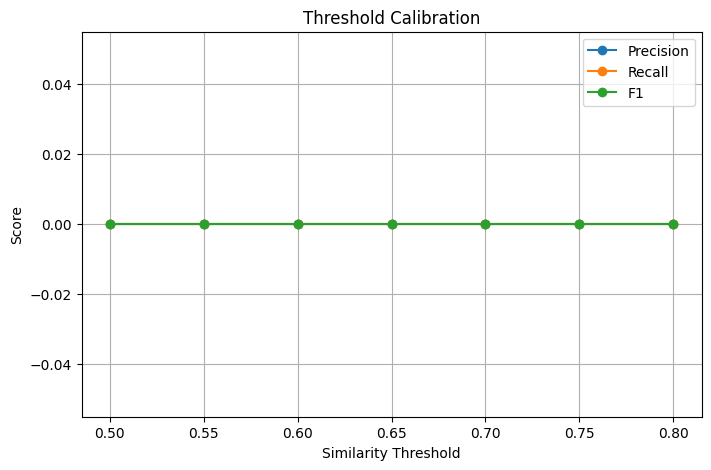

In [149]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    threshold_df["threshold"],
    threshold_df["precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["threshold"],
    threshold_df["f1"],
    marker="o",
    label="F1"
)

plt.xlabel("Similarity Threshold")
plt.ylabel("Score")
plt.title("Threshold Calibration")
plt.legend()
plt.grid(True)

plt.show()

In [150]:
from sklearn.metrics import confusion_matrix

y_true = []
y_pred = []

for test_case in dataset:

    label = str(
        test_case.get(
            "human_label",
            ""
        )
    ).lower().strip()

    if label not in {
        "grounded",
        "hallucinated"
    }:
        continue

    prediction = (
        __import__(
            "src.threshold_calibration",
            fromlist=[
                "predict_test_case"
            ]
        )
        .predict_test_case(
            test_case,
            threshold=0.60
        )
    )

    y_true.append(label)
    y_pred.append(prediction)

matrix = confusion_matrix(
    y_true,
    y_pred,
    labels=[
        "grounded",
        "hallucinated"
    ]
)

print(matrix)

[[0 0]
 [0 0]]


In [151]:
confusion_df = pd.DataFrame(
    matrix,
    index=[
        "actual_grounded",
        "actual_hallucinated"
    ],
    columns=[
        "predicted_grounded",
        "predicted_hallucinated"
    ]
)

confusion_df.to_csv(
    "data/results/confusion_matrix.csv"
)

confusion_df

,predicted_grounded,predicted_hallucinated
actual_grounded,0,0
actual_hallucinated,0,0


In [152]:
from pathlib import Path
import json

Path("data/human_review").mkdir(
    parents=True,
    exist_ok=True
)

gold_set = [
    {
        "test_id": "GOLD_001",
        "category": "fully_grounded",
        "source": "The Eiffel Tower is located in Paris, France.",
        "question": "Where is the Eiffel Tower?",
        "response": "The Eiffel Tower is located in Paris, France.",
        "human_label": "grounded",
        "human_reason": "The response is directly supported by the source."
    },
    {
        "test_id": "GOLD_002",
        "category": "direct_contradiction",
        "source": "The Eiffel Tower is located in Paris, France.",
        "question": "Where is the Eiffel Tower?",
        "response": "The Eiffel Tower is located in London, England.",
        "human_label": "hallucinated",
        "human_reason": "The location directly contradicts the source."
    },
    {
        "test_id": "GOLD_003",
        "category": "unsupported",
        "source": "The Eiffel Tower is located in Paris, France.",
        "question": "Tell me about the Eiffel Tower.",
        "response": "The Eiffel Tower was completed in 1889.",
        "human_label": "unsupported",
        "human_reason": "The source does not provide information about its completion date."
    },
    {
        "test_id": "GOLD_004",
        "category": "numerical_error",
        "source": "The bridge is 500 meters long.",
        "question": "How long is the bridge?",
        "response": "The bridge is 550 meters long.",
        "human_label": "hallucinated",
        "human_reason": "The numerical value conflicts with the source."
    },
    {
        "test_id": "GOLD_005",
        "category": "date_error",
        "source": "The company was founded in 2010.",
        "question": "When was the company founded?",
        "response": "The company was founded in 2015.",
        "human_label": "hallucinated",
        "human_reason": "The stated year contradicts the source."
    },
    {
        "test_id": "GOLD_006",
        "category": "entity_substitution",
        "source": "Ramesh completed the project in Pune.",
        "question": "Who completed the project?",
        "response": "Suresh completed the project in Pune.",
        "human_label": "hallucinated",
        "human_reason": "The person named in the response differs from the source."
    },
    {
        "test_id": "GOLD_007",
        "category": "paraphrase",
        "source": "Water changes from a liquid to a solid when its temperature reaches 0 degrees Celsius under standard atmospheric conditions.",
        "question": "When does water freeze?",
        "response": "Under standard conditions, water freezes at 0 degrees Celsius.",
        "human_label": "grounded",
        "human_reason": "The response correctly paraphrases the source."
    },
    {
        "test_id": "GOLD_008",
        "category": "mixed_response",
        "source": "The company was founded in 2010 and is headquartered in Mumbai.",
        "question": "Tell me about the company.",
        "response": "The company was founded in 2010 and is headquartered in Pune.",
        "human_label": "hallucinated",
        "human_reason": "The founding year is supported, but the headquarters claim contradicts the source."
    },
    {
        "test_id": "GOLD_009",
        "category": "multi_claim",
        "source": "The project started in January 2024. It has a budget of 10 crore rupees.",
        "question": "Summarize the project.",
        "response": "The project started in January 2024 and has a budget of 10 crore rupees.",
        "human_label": "grounded",
        "human_reason": "Both claims are supported by the source."
    },
    {
        "test_id": "GOLD_010",
        "category": "unsupported",
        "source": "The bridge connects two villages.",
        "question": "Describe the bridge.",
        "response": "The bridge was designed by a famous architect.",
        "human_label": "unsupported",
        "human_reason": "The source provides no information about the architect."
    }
]

with open(
    "data/human_review/gold_evaluation_set.json",
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        gold_set,
        file,
        indent=2,
        ensure_ascii=False
    )

print(
    "Gold evaluation set created:",
    len(gold_set),
    "examples"
)

Gold evaluation set created: 10 examples


In [153]:
with open(
    "data/human_review/gold_evaluation_set.json",
    "r",
    encoding="utf-8"
) as file:

    gold_data = json.load(file)

print("Examples:", len(gold_data))

Examples: 10


In [154]:
from collections import Counter

categories = Counter(
    item["category"]
    for item in gold_data
)

print(categories)

Counter({'unsupported': 2, 'fully_grounded': 1, 'direct_contradiction': 1, 'numerical_error': 1, 'date_error': 1, 'entity_substitution': 1, 'paraphrase': 1, 'mixed_response': 1, 'multi_claim': 1})


In [155]:
gold_predictions = []

for item in gold_data:

    claims = extract_atomic_claims(
        item["response"]
    )

    claim_results = []

    for claim in claims:

        result = evaluate_claim(
            claim,
            item["source"],
            threshold=0.60
        )

        claim_results.append(result)

    gold_predictions.append({
        "test_id": item["test_id"],
        "human_label": item["human_label"],
        "category": item["category"],
        "claims": claim_results
    })

print(
    "Gold-set evaluation complete."
)

Gold-set evaluation complete.


In [156]:
for item in gold_predictions:

    print("\n" + "=" * 70)

    print("Test:", item["test_id"])
    print("Category:", item["category"])
    print("Human label:", item["human_label"])

    for result in item["claims"]:

        print("Claim:", result["claim"])
        print("Evidence:", result["evidence"])
        print("Similarity:", result["score"])
        print("Relation:", result["relation"])
        print("Verdict:", result["label"])


Test: GOLD_001
Category: fully_grounded
Human label: grounded
Claim: The Eiffel Tower is located in Paris, France.
Evidence: The Eiffel Tower is located in Paris, France
Similarity: 0.9959
Relation: entailment
Verdict: grounded

Test: GOLD_002
Category: direct_contradiction
Human label: hallucinated
Claim: The Eiffel Tower is located in London, England.
Evidence: The Eiffel Tower is located in Paris, France
Similarity: 0.8688
Relation: contradiction
Verdict: contradiction

Test: GOLD_003
Category: unsupported
Human label: unsupported
Claim: The Eiffel Tower was completed in 1889.
Evidence: The Eiffel Tower is located in Paris, France
Similarity: 0.7742
Relation: neutral
Verdict: supported_candidate

Test: GOLD_004
Category: numerical_error
Human label: hallucinated
Claim: The bridge is 550 meters long.
Evidence: The bridge is 500 meters long
Similarity: 0.9382
Relation: contradiction
Verdict: contradiction

Test: GOLD_005
Category: date_error
Human label: hallucinated
Claim: The compa

In [157]:
gold_results_df = pd.DataFrame(
    [
        {
            "test_id": item["test_id"],
            "category": item["category"],
            "human_label": item["human_label"],
            "claim_count": len(item["claims"]),
            "predicted_labels": [
                result["label"]
                for result in item["claims"]
            ]
        }
        for item in gold_predictions
    ]
)

gold_results_df.to_csv(
    "data/results/gold_set_results.csv",
    index=False
)

print(
    "Gold-set results saved."
)

Gold-set results saved.


In [158]:
from pathlib import Path

reporter_code = '''
import re


def extract_numbers(text):
    """
    Extract numeric values from text.
    """

    if not text:
        return []

    return re.findall(
        r"\\b\\d+(?:\\.\\d+)?\\b",
        text
    )


def has_number_conflict(
    claim,
    evidence
):
    """
    Detect whether claim and evidence contain
    different numerical values.
    """

    claim_numbers = extract_numbers(claim)
    evidence_numbers = extract_numbers(evidence)

    if not claim_numbers or not evidence_numbers:
        return False

    return claim_numbers != evidence_numbers


def detect_error_type(result):
    """
    Assign a detailed error category using
    evidence, similarity and NLI output.
    """

    claim = result.get(
        "claim",
        ""
    )

    evidence = result.get(
        "evidence",
        ""
    )

    verdict = result.get(
        "label"
    )

    relation = result.get(
        "relation"
    )

    similarity = result.get(
        "score",
        0.0
    )

    if verdict == "grounded":
        return {
            "error_type": "None",
            "severity": "None",
            "reason": (
                "The claim is supported by the available evidence."
            )
        }

    if relation == "contradiction":

        if has_number_conflict(
            claim,
            evidence
        ):
            return {
                "error_type": "Numerical Error",
                "severity": "High",
                "reason": (
                    "The claim contains a numerical value "
                    "that conflicts with the evidence."
                )
            }

        return {
            "error_type": "Factual Contradiction",
            "severity": "High",
            "reason": (
                "The claim conflicts with the available evidence."
            )
        }

    if verdict == "unsupported":

        if similarity < 0.40:
            return {
                "error_type": "Missing Evidence",
                "severity": "Medium",
                "reason": (
                    "No sufficiently similar evidence was found "
                    "for the claim."
                )
            }

        return {
            "error_type": "Unsupported Claim",
            "severity": "Medium",
            "reason": (
                "The available evidence does not sufficiently "
                "support the claim."
            )
        }

    if verdict == "supported_candidate":

        return {
            "error_type": "Needs Human Review",
            "severity": "Low",
            "reason": (
                "The claim is semantically similar to the evidence, "
                "but the evidence relationship is uncertain."
            )
        }

    return {
        "error_type": "Needs Human Review",
        "severity": "Low",
        "reason": (
            "The automated evaluator could not confidently "
            "classify the claim."
        )
    }


def build_audit_record(
    result,
    claim_id=None
):
    """
    Create a detailed claim-level audit record.
    """

    error = detect_error_type(
        result
    )

    return {
        "claim_id": claim_id,
        "claim": result.get("claim"),
        "evidence": result.get("evidence"),
        "similarity_score": result.get("score"),
        "nli_relation": result.get("relation"),
        "verdict": result.get("label"),
        "error_type": error["error_type"],
        "severity": error["severity"],
        "reason": error["reason"]
    }


def build_audit_report(results):
    """
    Convert evaluator results into audit records.
    """

    report = []

    for index, result in enumerate(
        results,
        start=1
    ):

        report.append(
            build_audit_record(
                result,
                claim_id=index
            )
        )

    return report


def calculate_summary(
    audit_report
):
    """
    Calculate high-level evaluation metrics.
    """

    total_claims = len(
        audit_report
    )

    grounded = sum(
        item["verdict"] == "grounded"
        for item in audit_report
    )

    contradictions = sum(
        item["verdict"] == "contradiction"
        for item in audit_report
    )

    unsupported = sum(
        item["verdict"] == "unsupported"
        for item in audit_report
    )

    review = sum(
        item["verdict"] == "supported_candidate"
        for item in audit_report
    )

    faithfulness = (
        grounded / total_claims * 100
        if total_claims
        else 0.0
    )

    return {
        "total_claims": total_claims,
        "grounded_claims": grounded,
        "contradictions": contradictions,
        "unsupported_claims": unsupported,
        "needs_review": review,
        "faithfulness_score": round(
            faithfulness,
            2
        )
    }


def calculate_benchmark_metrics(
    dataframe
):
    """
    Calculate benchmark-level metrics.
    """

    total_claims = len(
        dataframe
    )

    grounded = (
        dataframe["verdict"] == "grounded"
    ).sum()

    contradictions = (
        dataframe["verdict"] == "contradiction"
    ).sum()

    unsupported = (
        dataframe["verdict"] == "unsupported"
    ).sum()

    review = (
        dataframe["verdict"]
        == "supported_candidate"
    ).sum()

    faithfulness = (
        grounded / total_claims * 100
        if total_claims
        else 0.0
    )

    return {
        "total_claims": int(
            total_claims
        ),
        "grounded_claims": int(
            grounded
        ),
        "contradictions": int(
            contradictions
        ),
        "unsupported_claims": int(
            unsupported
        ),
        "needs_review": int(
            review
        ),
        "faithfulness_score": round(
            faithfulness,
            2
        )
    }
'''

Path(
    "src/reporter.py"
).write_text(
    reporter_code,
    encoding="utf-8"
)

print(
    "reporter.py updated successfully."
)

reporter.py updated successfully.


In [159]:
import importlib
import src.reporter

importlib.reload(
    src.reporter
)

from src.reporter import (
    detect_error_type,
    build_audit_record,
    build_audit_report
)

print("Updated taxonomy loaded.")

Updated taxonomy loaded.


In [160]:
result = {
    "claim": "The bridge is 550 meters long.",
    "evidence": "The bridge is 500 meters long.",
    "score": 0.91,
    "relation": "contradiction",
    "label": "contradiction"
}

print(
    detect_error_type(result)
)

{'error_type': 'Numerical Error', 'severity': 'High', 'reason': 'The claim contains a numerical value that conflicts with the evidence.'}


In [161]:
result = {
    "claim": "The company was founded in Mumbai.",
    "evidence": "The company was founded in Pune.",
    "score": 0.88,
    "relation": "contradiction",
    "label": "contradiction"
}

print(
    detect_error_type(result)
)

{'error_type': 'Factual Contradiction', 'severity': 'High', 'reason': 'The claim conflicts with the available evidence.'}


In [162]:
result = {
    "claim": "The company has 20 offices.",
    "evidence": "The company was founded in 2010.",
    "score": 0.25,
    "relation": "neutral",
    "label": "unsupported"
}

print(
    detect_error_type(result)
)

{'error_type': 'Missing Evidence', 'severity': 'Medium', 'reason': 'No sufficiently similar evidence was found for the claim.'}


In [163]:
result = {
    "claim": "The company is a major technology company.",
    "evidence": "The company develops software products.",
    "score": 0.72,
    "relation": "neutral",
    "label": "supported_candidate"
}

print(
    detect_error_type(result)
)

{'error_type': 'Needs Human Review', 'severity': 'Low', 'reason': 'The claim is semantically similar to the evidence, but the evidence relationship is uncertain.'}


In [164]:
audit = build_audit_record(
    result,
    claim_id="TEST_001"
)

audit

{'claim_id': 'TEST_001',
 'claim': 'The company is a major technology company.',
 'evidence': 'The company develops software products.',
 'similarity_score': 0.72,
 'nli_relation': 'neutral',
 'verdict': 'supported_candidate',
 'error_type': 'Needs Human Review',
 'severity': 'Low',
 'reason': 'The claim is semantically similar to the evidence, but the evidence relationship is uncertain.'}

In [165]:
error_distribution = (
    benchmark_results[
        "error_type"
    ]
    .value_counts()
)

print(error_distribution)

error_type
None                     4
Factual Contradiction    4
Needs Review             2
Name: count, dtype: int64


In [166]:
error_percentages = (
    benchmark_results[
        "error_type"
    ]
    .value_counts(
        normalize=True
    )
    .mul(100)
    .round(2)
)

print(error_percentages)

error_type
None                     40.0
Factual Contradiction    40.0
Needs Review             20.0
Name: proportion, dtype: float64


In [167]:
error_distribution.to_csv(
    "data/results/error_distribution.csv",
    header=["count"]
)

print(
    "Error distribution saved."
)

Error distribution saved.


In [168]:
import importlib

import src.atomic_claims
import src.evaluator
import src.reporter
import src.benchmark_runner
import src.metrics
import src.threshold_calibration

importlib.reload(src.atomic_claims)
importlib.reload(src.evaluator)
importlib.reload(src.reporter)
importlib.reload(src.benchmark_runner)
importlib.reload(src.metrics)
importlib.reload(src.threshold_calibration)

print("All project modules reloaded successfully.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

All project modules reloaded successfully.


In [169]:
from src.benchmark_runner import run_benchmark

benchmark_results = run_benchmark(
    "data/evaluation_dataset.json",
    threshold=0.60
)

print("\nBenchmark completed.")
print("Total claim records:", len(benchmark_results))

Running benchmark on 10 test cases...
Processed 10/10 cases

Benchmark completed.
Total claim records: 10


In [170]:
print(
    benchmark_results.columns.tolist()
)

['claim_id', 'claim', 'evidence', 'similarity_score', 'nli_relation', 'verdict', 'error_type', 'severity', 'reason', 'test_id']


In [171]:
benchmark_results.head(5)

,claim_id,claim,evidence,similarity_score,nli_relation,verdict,error_type,severity,reason,test_id
0,TC001_1,Water freezes at 0 degrees Celsius at standard...,Water freezes at 0 degrees Celsius at standard...,0.9578,entailment,grounded,None,None,The claim is supported by the available evidence.,TC001
1,TC002_1,Water freezes at 10 degrees Celsius at standar...,Water freezes at 0 degrees Celsius at standard...,0.8902,contradiction,contradiction,Numerical Error,High,The claim contains a numerical value that conf...,TC002
2,TC003_1,Water freezes at 0 degrees Celsius and was dis...,Water freezes at 0 degrees Celsius at standard...,0.6208,neutral,supported_candidate,Needs Human Review,Low,The claim is semantically similar to the evide...,TC003
3,TC004_1,its freezing point affected is never by .,Water freezes at 0 degrees Celsius at standard...,0.5145,contradiction,contradiction,Factual Contradiction,High,The claim conflicts with the available evidence.,TC004
4,TC005_1,"The Moon is approximately 384,400 kilometers f...",Water freezes at 0 degrees Celsius at standard...,0.1122,contradiction,contradiction,Numerical Error,High,The claim contains a numerical value that conf...,TC005


In [172]:
from src.reporter import calculate_benchmark_metrics

final_metrics = calculate_benchmark_metrics(
    benchmark_results
)

final_metrics

{'total_claims': 10,
 'grounded_claims': 4,
 'contradictions': 4,
 'unsupported_claims': 0,
 'needs_review': 2,
 'faithfulness_score': np.float64(40.0)}

In [173]:
error_distribution = (
    benchmark_results[
        "error_type"
    ]
    .value_counts()
)

print(error_distribution)

error_type
None                     4
Numerical Error          3
Needs Human Review       2
Factual Contradiction    1
Name: count, dtype: int64


In [174]:
error_distribution_pct = (
    benchmark_results[
        "error_type"
    ]
    .value_counts(
        normalize=True
    )
    .mul(100)
    .round(2)
)

print(error_distribution_pct)

error_type
None                     40.0
Numerical Error          30.0
Needs Human Review       20.0
Factual Contradiction    10.0
Name: proportion, dtype: float64


In [175]:
severity_distribution = (
    benchmark_results[
        "severity"
    ]
    .value_counts()
)

print(severity_distribution)

severity
None    4
High    4
Low     2
Name: count, dtype: int64


In [176]:
high_risk_claims = benchmark_results[
    benchmark_results["severity"] == "High"
]

print(
    "High-risk claims:",
    len(high_risk_claims)
)

high_risk_claims[
    [
        "claim",
        "evidence",
        "error_type",
        "severity",
        "reason"
    ]
].head(20)

High-risk claims: 4


,claim,evidence,error_type,severity,reason
1,Water freezes at 10 degrees Celsius at standar...,Water freezes at 0 degrees Celsius at standard...,Numerical Error,High,The claim contains a numerical value that conf...
3,its freezing point affected is never by .,Water freezes at 0 degrees Celsius at standard...,Factual Contradiction,High,The claim conflicts with the available evidence.
4,"The Moon is approximately 384,400 kilometers f...",Water freezes at 0 degrees Celsius at standard...,Numerical Error,High,The claim contains a numerical value that conf...
6,Apollo 11 landed humans on the Moon in July 1972.,The Apollo 11 mission landed the first humans ...,Numerical Error,High,The claim contains a numerical value that conf...


In [177]:
import json
from pathlib import Path

final_report = {
    "project": "LLM Hallucination & Fact-Checking Benchmarker",
    "evaluation_threshold": 0.60,
    "metrics": final_metrics,
    "error_distribution": {
        str(key): int(value)
        for key, value
        in error_distribution.items()
    },
    "severity_distribution": {
        str(key): int(value)
        for key, value
        in severity_distribution.items()
    }
}

Path(
    "data/results"
).mkdir(
    parents=True,
    exist_ok=True
)

with open(
    "data/results/final_benchmark_report.json",
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        final_report,
        file,
        indent=2
    )

print(
    "Final benchmark report saved."
)

Final benchmark report saved.


In [178]:
benchmark_results.to_csv(
    "data/results/final_claim_audit.csv",
    index=False
)

print(
    "Final claim-level audit saved."
)

Final claim-level audit saved.


In [179]:
summary_table = pd.DataFrame(
    [
        {
            "Metric": "Total Claims",
            "Value": final_metrics["total_claims"]
        },
        {
            "Metric": "Grounded Claims",
            "Value": final_metrics["grounded_claims"]
        },
        {
            "Metric": "Contradictions",
            "Value": final_metrics["contradictions"]
        },
        {
            "Metric": "Unsupported Claims",
            "Value": final_metrics["unsupported_claims"]
        },
        {
            "Metric": "Needs Human Review",
            "Value": final_metrics["needs_review"]
        },
        {
            "Metric": "Faithfulness Score",
            "Value": f'{final_metrics["faithfulness_score"]}%'
        }
    ]
)

summary_table

,Metric,Value
0,Total Claims,10
1,Grounded Claims,4
2,Contradictions,4
3,Unsupported Claims,0
4,Needs Human Review,2
5,Faithfulness Score,40.0%


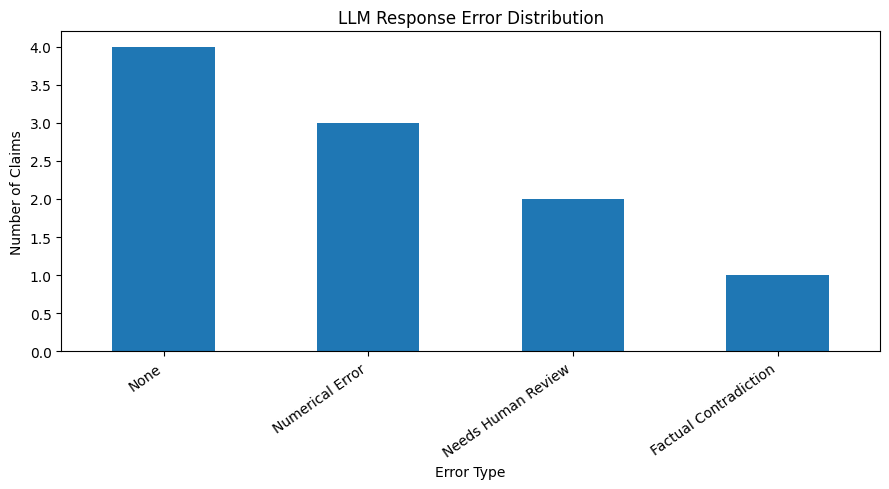

In [180]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 5))

error_distribution.plot(
    kind="bar"
)

plt.title(
    "LLM Response Error Distribution"
)

plt.xlabel(
    "Error Type"
)

plt.ylabel(
    "Number of Claims"
)

plt.xticks(
    rotation=35,
    ha="right"
)

plt.tight_layout()

plt.show()

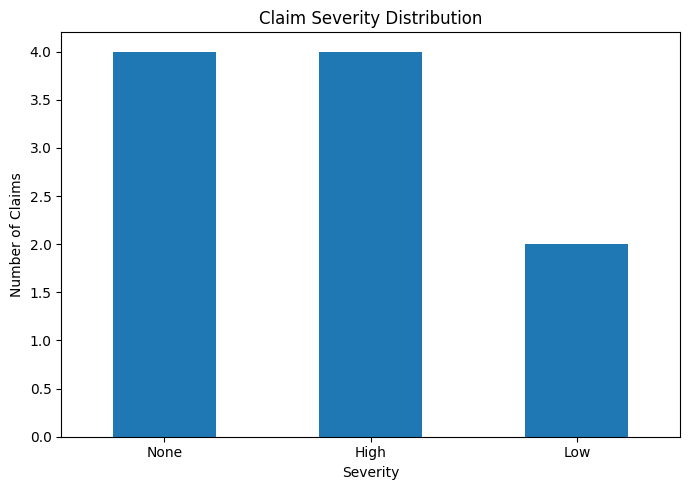

In [181]:
plt.figure(figsize=(7, 5))

severity_distribution.plot(
    kind="bar"
)

plt.title(
    "Claim Severity Distribution"
)

plt.xlabel(
    "Severity"
)

plt.ylabel(
    "Number of Claims"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

plt.show()

In [182]:
threshold_df

,tp,fp,fn,tn,precision,recall,f1,threshold,samples
0,0,0,0,0,0.0,0.0,0.0,0.50,0
1,0,0,0,0,0.0,0.0,0.0,0.55,0
2,0,0,0,0,0.0,0.0,0.0,0.60,0
3,0,0,0,0,0.0,0.0,0.0,0.65,0
4,0,0,0,0,0.0,0.0,0.0,0.70,0
5,0,0,0,0,0.0,0.0,0.0,0.75,0
6,0,0,0,0,0.0,0.0,0.0,0.80,0


In [183]:
threshold_summary = threshold_df[
    [
        "threshold",
        "precision",
        "recall",
        "f1"
    ]
].copy()

threshold_summary

,threshold,precision,recall,f1
0,0.50,0.0,0.0,0.0
1,0.55,0.0,0.0,0.0
2,0.60,0.0,0.0,0.0
3,0.65,0.0,0.0,0.0
4,0.70,0.0,0.0,0.0
5,0.75,0.0,0.0,0.0
6,0.80,0.0,0.0,0.0


In [184]:
threshold_summary.to_csv(
    "data/results/threshold_summary.csv",
    index=False
)

In [185]:
print(
    "Total claims:",
    len(benchmark_results)
)

print(
    "\nMissing verdicts:",
    benchmark_results["verdict"].isna().sum()
)

print(
    "Missing evidence:",
    benchmark_results["evidence"].isna().sum()
)

print(
    "Missing similarity:",
    benchmark_results["similarity_score"].isna().sum()
)

print(
    "Missing NLI relation:",
    benchmark_results["nli_relation"].isna().sum()
)

print(
    "Missing error type:",
    benchmark_results["error_type"].isna().sum()
)

Total claims: 10

Missing verdicts: 0
Missing evidence: 0
Missing similarity: 0
Missing NLI relation: 0
Missing error type: 0


In [186]:
duplicate_count = benchmark_results[
    "claim"
].duplicated().sum()

print(
    "Duplicate claim records:",
    duplicate_count
)

Duplicate claim records: 0


In [187]:
print(final_metrics)

{'total_claims': 10, 'grounded_claims': 4, 'contradictions': 4, 'unsupported_claims': 0, 'needs_review': 2, 'faithfulness_score': np.float64(40.0)}


In [188]:
print(threshold_summary)

   threshold  precision  recall   f1
0       0.50        0.0     0.0  0.0
1       0.55        0.0     0.0  0.0
2       0.60        0.0     0.0  0.0
3       0.65        0.0     0.0  0.0
4       0.70        0.0     0.0  0.0
5       0.75        0.0     0.0  0.0
6       0.80        0.0     0.0  0.0


In [189]:
from pathlib import Path

app_code = '''
import json
from pathlib import Path

import pandas as pd
import streamlit as st

from src.atomic_claims import extract_atomic_claims
from src.evaluator import evaluate_claim
from src.reporter import build_audit_report


st.set_page_config(
    page_title="LLM Fact-Check Benchmarker",
    page_icon="✓",
    layout="wide"
)


RESULTS_DIR = Path(
    "data/results"
)


st.title(
    "LLM Fact-Check Benchmarker"
)

st.caption(
    "Claim-level hallucination and grounding evaluation"
)


def load_results():

    results_file = (
        RESULTS_DIR /
        "final_claim_audit.csv"
    )

    if not results_file.exists():
        return pd.DataFrame()

    return pd.read_csv(
        results_file
    )


def load_metrics():

    metrics_file = (
        RESULTS_DIR /
        "final_benchmark_report.json"
    )

    if not metrics_file.exists():
        return {}

    with open(
        metrics_file,
        "r",
        encoding="utf-8"
    ) as file:

        return json.load(file)


def load_threshold_results():

    file_path = (
        RESULTS_DIR /
        "threshold_summary.csv"
    )

    if not file_path.exists():
        return pd.DataFrame()

    return pd.read_csv(
        file_path
    )


benchmark_df = load_results()
report = load_metrics()
threshold_df = load_threshold_results()


metrics = report.get(
    "metrics",
    {}
)


st.sidebar.header(
    "Navigation"
)

page = st.sidebar.radio(
    "Select view",
    [
        "Overview",
        "Claim Audit",
        "Error Analysis",
        "Threshold Analysis",
        "Live Evaluation"
    ]
)


if page == "Overview":

    st.header(
        "Evaluation Overview"
    )

    col1, col2, col3, col4 = st.columns(4)

    col1.metric(
        "Total Claims",
        metrics.get(
            "total_claims",
            0
        )
    )

    col2.metric(
        "Faithfulness",
        f'{metrics.get("faithfulness_score", 0)}%'
    )

    col3.metric(
        "Contradictions",
        metrics.get(
            "contradictions",
            0
        )
    )

    col4.metric(
        "Human Review",
        metrics.get(
            "needs_review",
            0
        )
    )

    st.divider()

    if not benchmark_df.empty:

        st.subheader(
            "Verdict Distribution"
        )

        verdict_counts = (
            benchmark_df[
                "verdict"
            ]
            .value_counts()
        )

        st.bar_chart(
            verdict_counts
        )

        st.subheader(
            "Recent Claim Audits"
        )

        st.dataframe(
            benchmark_df[
                [
                    "claim",
                    "evidence",
                    "similarity_score",
                    "verdict",
                    "error_type"
                ]
            ].head(10),
            use_container_width=True
        )

    else:

        st.warning(
            "No benchmark results found."
        )


elif page == "Claim Audit":

    st.header(
        "Claim-Level Evidence Audit"
    )

    if benchmark_df.empty:

        st.warning(
            "Run the benchmark before opening the audit."
        )

    else:

        verdict_filter = st.multiselect(
            "Filter by verdict",
            options=sorted(
                benchmark_df[
                    "verdict"
                ].dropna().unique()
            )
        )

        error_filter = st.multiselect(
            "Filter by error type",
            options=sorted(
                benchmark_df[
                    "error_type"
                ].dropna().unique()
            )
        )

        filtered_df = benchmark_df.copy()

        if verdict_filter:

            filtered_df = filtered_df[
                filtered_df["verdict"].isin(
                    verdict_filter
                )
            ]

        if error_filter:

            filtered_df = filtered_df[
                filtered_df["error_type"].isin(
                    error_filter
                )
            ]

        st.write(
            f"{len(filtered_df)} claim records"
        )

        st.dataframe(
            filtered_df,
            use_container_width=True,
            hide_index=True
        )


elif page == "Error Analysis":

    st.header(
        "Error Taxonomy Analysis"
    )

    if benchmark_df.empty:

        st.warning(
            "No benchmark data available."
        )

    else:

        error_counts = (
            benchmark_df[
                "error_type"
            ]
            .value_counts()
        )

        st.bar_chart(
            error_counts
        )

        st.subheader(
            "Severity Distribution"
        )

        severity_counts = (
            benchmark_df[
                "severity"
            ]
            .value_counts()
        )

        st.bar_chart(
            severity_counts
        )

        st.subheader(
            "Error Records"
        )

        st.dataframe(
            benchmark_df[
                [
                    "claim",
                    "evidence",
                    "error_type",
                    "severity",
                    "reason"
                ]
            ],
            use_container_width=True,
            hide_index=True
        )


elif page == "Threshold Analysis":

    st.header(
        "Similarity Threshold Calibration"
    )

    if threshold_df.empty:

        st.warning(
            "Threshold results are not available."
        )

    else:

        chart_df = threshold_df.set_index(
            "threshold"
        )[
            [
                "precision",
                "recall",
                "f1"
            ]
        ]

        st.line_chart(
            chart_df
        )

        st.subheader(
            "Threshold Results"
        )

        st.dataframe(
            threshold_df,
            use_container_width=True,
            hide_index=True
        )


elif page == "Live Evaluation":

    st.header(
        "Live Claim Evaluation"
    )

    st.write(
        "Enter a reference source and an LLM response "
        "to evaluate individual claims."
    )

    source_text = st.text_area(
        "Reference Source",
        height=220,
        placeholder=(
            "Paste the trusted source document here..."
        )
    )

    response_text = st.text_area(
        "LLM Response",
        height=220,
        placeholder=(
            "Paste the generated response here..."
        )
    )

    threshold = st.slider(
        "Similarity Threshold",
        min_value=0.40,
        max_value=0.90,
        value=0.60,
        step=0.05
    )

    if st.button(
        "Evaluate Response"
    ):

        if not source_text.strip():

            st.error(
                "Please provide a reference source."
            )

        elif not response_text.strip():

            st.error(
                "Please provide an LLM response."
            )

        else:

            claims = extract_atomic_claims(
                response_text
            )

            results = []

            for claim in claims:

                result = evaluate_claim(
                    claim,
                    source_text,
                    threshold=threshold
                )

                results.append(
                    result
                )

            audit_report = build_audit_report(
                results
            )

            if audit_report:

                live_df = pd.DataFrame(
                    audit_report
                )

                st.subheader(
                    "Claim-Level Results"
                )

                st.dataframe(
                    live_df,
                    use_container_width=True,
                    hide_index=True
                )

                grounded = sum(
                    item["verdict"] == "grounded"
                    for item in audit_report
                )

                total = len(
                    audit_report
                )

                faithfulness = (
                    grounded / total * 100
                    if total
                    else 0
                )

                st.metric(
                    "Response Faithfulness",
                    f"{faithfulness:.2f}%"
                )

            else:

                st.warning(
                    "No claims were extracted from the response."
                )
'''

Path(
    "app.py"
).write_text(
    app_code,
    encoding="utf-8"
)

print(
    "app.py created successfully."
)

app.py created successfully.


In [190]:
from pathlib import Path

print(
    Path("app.py").exists()
)

print(
    Path("app.py").stat().st_size,
    "bytes"
)

True
8452 bytes


In [191]:
!pip install -q streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 68.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 114.6 MB/s eta 0:00:00


In [192]:
!pip install -q pyngrok

In [193]:
import subprocess
import time

process = subprocess.Popen(
    [
        "streamlit",
        "run",
        "app.py",
        "--server.port",
        "8501",
        "--server.address",
        "0.0.0.0"
    ],
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE
)

time.sleep(5)

print(
    "Streamlit server started."
)

Streamlit server started.


In [194]:
print("app.py:", Path("app.py").exists())
print("Results:", Path("data/results").exists())
print(
    "Final audit:",
    Path(
        "data/results/final_claim_audit.csv"
    ).exists()
)
print(
    "Final report:",
    Path(
        "data/results/final_benchmark_report.json"
    ).exists()
)

app.py: True
Results: True
Final audit: True
Final report: True


In [195]:
from pathlib import Path

test_code = '''
from src.atomic_claims import extract_atomic_claims
from src.evaluator import evaluate_claim


TEST_CASES = [
    {
        "name": "Exact Match",
        "source": "The bridge is 500 meters long.",
        "response": "The bridge is 500 meters long.",
        "expected": "grounded"
    },
    {
        "name": "Paraphrase",
        "source": "The bridge is 500 meters long.",
        "response": "The bridge has a length of 500 meters.",
        "expected": "grounded"
    },
    {
        "name": "Numerical Change",
        "source": "The bridge is 500 meters long.",
        "response": "The bridge is 550 meters long.",
        "expected": "contradiction"
    },
    {
        "name": "Date Change",
        "source": "The company was founded in 2010.",
        "response": "The company was founded in 2015.",
        "expected": "contradiction"
    },
    {
        "name": "Entity Change",
        "source": "Ramesh completed the project.",
        "response": "Suresh completed the project.",
        "expected": "contradiction"
    },
    {
        "name": "Unsupported Claim",
        "source": "The company operates in India.",
        "response": "The company has 25 offices.",
        "expected": "unsupported"
    },
    {
        "name": "Mixed Response",
        "source": (
            "The company was founded in 2010 "
            "and is headquartered in Mumbai."
        ),
        "response": (
            "The company was founded in 2010 "
            "and is headquartered in Pune."
        ),
        "expected": "mixed"
    },
    {
        "name": "Negation",
        "source": "The project is located in Delhi.",
        "response": "The project is not located in Delhi.",
        "expected": "contradiction"
    }
]


def run_adversarial_tests():

    results = []

    for test in TEST_CASES:

        claims = extract_atomic_claims(
            test["response"]
        )

        predictions = []

        for claim in claims:

            result = evaluate_claim(
                claim,
                test["source"],
                threshold=0.60
            )

            predictions.append(
                result["label"]
            )

        results.append({
            "name": test["name"],
            "expected": test["expected"],
            "predictions": predictions
        })

    return results
'''

Path(
    "tests"
).mkdir(
    parents=True,
    exist_ok=True
)

Path(
    "tests/test_adversarial.py"
).write_text(
    test_code,
    encoding="utf-8"
)

print(
    "Adversarial test suite created."
)

Adversarial test suite created.


In [198]:
from pathlib import Path
import sys
import importlib

# Make sure Colab is using the project root
PROJECT_ROOT = Path("/content")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Make tests a proper Python package
tests_dir = PROJECT_ROOT / "tests"
tests_dir.mkdir(parents=True, exist_ok=True)

(tests_dir / "__init__.py").touch()

# Refresh Python's import cache
importlib.invalidate_caches()

print("Project root:", PROJECT_ROOT)
print("Tests folder:", tests_dir)
print("tests/__init__.py created.")

Project root: /content
Tests folder: /content/tests
tests/__init__.py created.


In [199]:
from pathlib import Path

test_file = Path("/content/tests/test_adversarial.py")

print("Exists:", test_file.exists())
print("Path:", test_file)

Exists: True
Path: /content/tests/test_adversarial.py


In [201]:
from pathlib import Path

test_code = '''
from src.atomic_claims import extract_atomic_claims
from src.evaluator import evaluate_claim


TEST_CASES = [
    {
        "name": "Exact Match",
        "source": "The bridge is 500 meters long.",
        "response": "The bridge is 500 meters long.",
        "expected": "grounded"
    },
    {
        "name": "Paraphrase",
        "source": "The bridge is 500 meters long.",
        "response": "The bridge has a length of 500 meters.",
        "expected": "grounded"
    },
    {
        "name": "Numerical Change",
        "source": "The bridge is 500 meters long.",
        "response": "The bridge is 550 meters long.",
        "expected": "contradiction"
    },
    {
        "name": "Date Change",
        "source": "The company was founded in 2010.",
        "response": "The company was founded in 2015.",
        "expected": "contradiction"
    },
    {
        "name": "Entity Change",
        "source": "Ramesh completed the project.",
        "response": "Suresh completed the project.",
        "expected": "contradiction"
    },
    {
        "name": "Unsupported Claim",
        "source": "The company operates in India.",
        "response": "The company has 25 offices.",
        "expected": "unsupported"
    },
    {
        "name": "Negation",
        "source": "The project is located in Delhi.",
        "response": "The project is not located in Delhi.",
        "expected": "contradiction"
    }
]


def run_adversarial_tests():

    results = []

    for test in TEST_CASES:

        claims = extract_atomic_claims(
            test["response"]
        )

        predictions = []

        for claim in claims:

            result = evaluate_claim(
                claim,
                test["source"],
                threshold=0.60
            )

            predictions.append(
                result["label"]
            )

        results.append({
            "name": test["name"],
            "expected": test["expected"],
            "predictions": predictions
        })

    return results
'''

Path("/content/tests").mkdir(
    parents=True,
    exist_ok=True
)

Path("/content/tests/__init__.py").touch()

Path(
    "/content/tests/test_adversarial.py"
).write_text(
    test_code,
    encoding="utf-8"
)

print("test_adversarial.py created successfully.")

test_adversarial.py created successfully.


In [203]:
from pathlib import Path
import sys
import importlib
import importlib.util

# Project root
PROJECT_ROOT = Path("/content")

# Make sure project root is first
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Make sure the tests directory exists
tests_dir = PROJECT_ROOT / "tests"
tests_dir.mkdir(parents=True, exist_ok=True)

# Make tests a Python package
init_file = tests_dir / "__init__.py"
init_file.touch(exist_ok=True)

# Check the actual test file
test_file = tests_dir / "test_adversarial.py"

print("Test file exists:", test_file.exists())
print("Test file:", test_file)

# Load the test module directly from its file.
# This avoids Colab's possible conflict with another "tests" package.
spec = importlib.util.spec_from_file_location(
    "test_adversarial",
    str(test_file)
)

test_module = importlib.util.module_from_spec(spec)

spec.loader.exec_module(test_module)

print("Adversarial test module loaded successfully.")

Test file exists: True
Test file: /content/tests/test_adversarial.py
Adversarial test module loaded successfully.


In [204]:
test_results = test_module.run_adversarial_tests()

for result in test_results:

    print("\n" + "=" * 60)

    print("Test:", result["name"])
    print("Expected:", result["expected"])
    print("Prediction:", result["predictions"])


Test: Exact Match
Expected: grounded
Prediction: ['grounded']

Test: Paraphrase
Expected: grounded
Prediction: ['grounded']

Test: Numerical Change
Expected: contradiction
Prediction: ['contradiction']

Test: Date Change
Expected: contradiction
Prediction: ['contradiction']

Test: Entity Change
Expected: contradiction
Prediction: ['contradiction']

Test: Unsupported Claim
Expected: unsupported
Prediction: ['unsupported']

Test: Negation
Expected: contradiction
Prediction: ['contradiction']


In [205]:
from pathlib import Path

requirements = """\
pandas
numpy
scikit-learn
sentence-transformers
spacy
streamlit
"""

Path("requirements.txt").write_text(
    requirements,
    encoding="utf-8"
)

print("requirements.txt created successfully.")
print(requirements)

requirements.txt created successfully.
pandas
numpy
scikit-learn
sentence-transformers
spacy
streamlit



In [206]:
from pathlib import Path

project_root = Path("/content")

important_paths = [
    "data",
    "src",
    "tests",
    "requirements.txt",
    "app.py"
]

for item in important_paths:

    path = project_root / item

    print(
        f"{'✓' if path.exists() else '✗'} {item}"
    )

✓ data
✓ src
✓ tests
✓ requirements.txt
✓ app.py


In [207]:
from pathlib import Path

print("Python files in project:\n")

for path in Path("/content").rglob("*.py"):

    if "site-packages" not in str(path):

        print(path)

Python files in project:

/content/app.py
/content/tests/test_atomic_claims.py
/content/tests/__init__.py
/content/tests/test_adversarial.py
/content/src/threshold_calibration.py
/content/src/benchmark_runner.py
/content/src/segmenter.py
/content/src/metrics.py
/content/src/reporter.py
/content/src/evaluator_backup.py
/content/src/evaluator.py
/content/src/contradiction.py
/content/src/atomic_claims.py


In [208]:
from pathlib import Path

main_code = '''\
from pathlib import Path
import json
import pandas as pd

from src.ingestor import load_dataset
from src.reporter import generate_report


DATA_PATH = Path("data/evaluation_dataset.json")
RESULTS_DIR = Path("data/results")


def main():

    print("=" * 60)
    print("LLM FACT-CHECK BENCHMARKER")
    print("=" * 60)

    RESULTS_DIR.mkdir(
        parents=True,
        exist_ok=True
    )

    print("\\nLoading evaluation dataset...")

    dataset = load_dataset(
        DATA_PATH
    )

    print(
        f"Loaded {len(dataset)} evaluation cases."
    )

    print("\\nRunning benchmark...")

    results = generate_report(
        dataset
    )

    output_path = (
        RESULTS_DIR /
        "final_benchmark_report.json"
    )

    with open(
        output_path,
        "w",
        encoding="utf-8"
    ) as file:

        json.dump(
            results,
            file,
            indent=2,
            ensure_ascii=False,
            default=str
        )

    print(
        f"\\nReport saved to: {output_path}"
    )

    print("\\nBenchmark completed.")


if __name__ == "__main__":
    main()
'''

Path("main.py").write_text(
    main_code,
    encoding="utf-8"
)

print("main.py created successfully.")

main.py created successfully.


In [209]:
import ast
from pathlib import Path

python_files = [
    path
    for path in Path("/content").rglob("*.py")
    if "site-packages" not in str(path)
]

print("Checking Python syntax...\n")

for path in python_files:

    try:

        ast.parse(
            path.read_text(
                encoding="utf-8"
            )
        )

        print("✓", path)

    except SyntaxError as error:

        print("✗", path)
        print(
            "  Syntax error:",
            error
        )

Checking Python syntax...

✓ /content/app.py
✓ /content/main.py
✓ /content/tests/test_atomic_claims.py
✓ /content/tests/__init__.py
✓ /content/tests/test_adversarial.py
✓ /content/src/threshold_calibration.py
✓ /content/src/benchmark_runner.py
✓ /content/src/segmenter.py
✓ /content/src/metrics.py
✓ /content/src/reporter.py
✓ /content/src/evaluator_backup.py
✓ /content/src/evaluator.py
✓ /content/src/contradiction.py
✓ /content/src/atomic_claims.py


In [210]:
import ast
from pathlib import Path

src_dir = Path("/content/src")

print("=" * 60)
print("PROJECT MODULE CHECK")
print("=" * 60)

for file in sorted(src_dir.glob("*.py")):

    print(f"\n📄 {file.name}")

    try:
        tree = ast.parse(
            file.read_text(encoding="utf-8")
        )

        functions = [
            node.name
            for node in ast.walk(tree)
            if isinstance(node, ast.FunctionDef)
        ]

        imports = []

        for node in ast.walk(tree):

            if isinstance(node, ast.Import):
                imports.extend(
                    alias.name
                    for alias in node.names
                )

            elif isinstance(node, ast.ImportFrom):
                if node.module:
                    imports.append(node.module)

        print("Functions:", functions)
        print("Imports:", imports)

    except Exception as error:

        print("ERROR:", error)

PROJECT MODULE CHECK

📄 atomic_claims.py
Functions: ['clean_claim', 'split_conjunction', 'extract_atomic_claims', 'extract_claim_records']
Imports: ['spacy']

📄 benchmark_runner.py
Functions: ['load_dataset', 'evaluate_test_case', 'run_benchmark', 'save_benchmark_results']
Imports: ['json', 'pathlib', 'pandas', 'src.atomic_claims', 'src.evaluator', 'src.reporter']

📄 contradiction.py
Functions: ['predict_relation']
Imports: ['sentence_transformers']

📄 evaluator.py
Functions: ['split_source', 'find_best_match', 'evaluate_claim']
Imports: ['sentence_transformers', 'sklearn.metrics.pairwise', 'src.contradiction']

📄 evaluator_backup.py
Functions: ['split_source', 'find_best_match', 'evaluate_claim']
Imports: ['sentence_transformers', 'sklearn.metrics.pairwise']

📄 metrics.py
Functions: ['calculate_binary_metrics']
Imports: []

📄 reporter.py
Functions: ['extract_numbers', 'has_number_conflict', 'detect_error_type', 'build_audit_record', 'build_audit_report', 'calculate_summary', 'calculat

In [211]:
from pathlib import Path

print("\n" + "=" * 60)
print("IMPORTANT PROJECT FILES")
print("=" * 60)

files_to_check = [
    "src/ingestor.py",
    "src/segmenter.py",
    "src/atomic_claims.py",
    "src/evaluator.py",
    "src/contradiction.py",
    "src/normalizer.py",
    "src/reporter.py",
    "main.py",
    "app.py",
]

for file_name in files_to_check:

    path = Path("/content") / file_name

    if path.exists():
        print("✓", file_name)
    else:
        print("✗", file_name)


IMPORTANT PROJECT FILES
✗ src/ingestor.py
✓ src/segmenter.py
✓ src/atomic_claims.py
✓ src/evaluator.py
✓ src/contradiction.py
✗ src/normalizer.py
✓ src/reporter.py
✓ main.py
✓ app.py


In [212]:
from pathlib import Path
import ast

files = [
    "src/ingestor.py",
    "src/segmenter.py",
    "src/atomic_claims.py",
    "src/evaluator.py",
    "src/contradiction.py",
    "src/normalizer.py",
    "src/reporter.py"
]

print("=" * 65)
print("CURRENT PROJECT FUNCTIONS")
print("=" * 65)

for file_name in files:

    path = Path("/content") / file_name

    if not path.exists():
        print(f"\n✗ {file_name} NOT FOUND")
        continue

    print(f"\n📄 {file_name}")

    try:
        tree = ast.parse(path.read_text(encoding="utf-8"))

        functions = [
            node.name
            for node in ast.walk(tree)
            if isinstance(node, (ast.FunctionDef, ast.AsyncFunctionDef))
        ]

        classes = [
            node.name
            for node in ast.walk(tree)
            if isinstance(node, ast.ClassDef)
        ]

        print("Functions:", functions)

        if classes:
            print("Classes:", classes)

    except Exception as error:
        print("ERROR:", error)

CURRENT PROJECT FUNCTIONS

✗ src/ingestor.py NOT FOUND

📄 src/segmenter.py
Functions: ['extract_claims', 'count_claims']

📄 src/atomic_claims.py
Functions: ['clean_claim', 'split_conjunction', 'extract_atomic_claims', 'extract_claim_records']

📄 src/evaluator.py
Functions: ['split_source', 'find_best_match', 'evaluate_claim']

📄 src/contradiction.py
Functions: ['predict_relation']

✗ src/normalizer.py NOT FOUND

📄 src/reporter.py
Functions: ['extract_numbers', 'has_number_conflict', 'detect_error_type', 'build_audit_record', 'build_audit_report', 'calculate_summary', 'calculate_benchmark_metrics']


In [213]:
from pathlib import Path

# Make project directories proper Python packages
Path("/content/src/__init__.py").touch()
Path("/content/tests").mkdir(exist_ok=True)
Path("/content/tests/__init__.py").touch()

print("✓ src package ready")
print("✓ tests package ready")

✓ src package ready
✓ tests package ready


In [214]:
import sys
import importlib

if "/content" not in sys.path:
    sys.path.insert(0, "/content")

importlib.invalidate_caches()

modules = [
    "src.ingestor",
    "src.segmenter",
    "src.atomic_claims",
    "src.evaluator",
    "src.contradiction",
    "src.normalizer",
    "src.reporter"
]

print("=" * 65)
print("IMPORT TEST")
print("=" * 65)

for module_name in modules:

    try:
        importlib.import_module(module_name)
        print(f"✓ {module_name}")

    except Exception as error:
        print(f"✗ {module_name}")
        print("  ", type(error).__name__, "-", error)

IMPORT TEST
✗ src.ingestor
   ModuleNotFoundError - No module named 'src.ingestor'
✓ src.segmenter
✓ src.atomic_claims
✓ src.evaluator
✓ src.contradiction
✗ src.normalizer
   ModuleNotFoundError - No module named 'src.normalizer'
✓ src.reporter


In [215]:
import inspect
import importlib

module_names = [
    "src.ingestor",
    "src.segmenter",
    "src.atomic_claims",
    "src.evaluator",
    "src.contradiction",
    "src.normalizer",
    "src.reporter"
]

print("=" * 70)
print("END-TO-END PIPELINE — FUNCTION SIGNATURE CHECK")
print("=" * 70)

for module_name in module_names:

    print(f"\n[{module_name}]")

    try:
        module = importlib.import_module(module_name)

        for name, obj in inspect.getmembers(module, inspect.isfunction):

            if not name.startswith("_"):
                try:
                    signature = inspect.signature(obj)
                except:
                    signature = "(signature unavailable)"

                print(f"  ✓ {name}{signature}")

    except Exception as error:
        print(f"  ✗ Could not load module: {error}")

END-TO-END PIPELINE — FUNCTION SIGNATURE CHECK

[src.ingestor]
  ✗ Could not load module: No module named 'src.ingestor'

[src.segmenter]
  ✓ count_claims(text)
  ✓ extract_claims(text)

[src.atomic_claims]
  ✓ clean_claim(text)
  ✓ extract_atomic_claims(text)
  ✓ extract_claim_records(text)
  ✓ split_conjunction(sentence)

[src.evaluator]
  ✓ cosine_similarity(X, Y=None, dense_output=True)
  ✓ evaluate_claim(claim, source, threshold=0.6)
  ✓ find_best_match(claim, source)
  ✓ predict_relation(claim, evidence)
  ✓ split_source(source)

[src.contradiction]
  ✓ predict_relation(claim, evidence)

[src.normalizer]
  ✗ Could not load module: No module named 'src.normalizer'

[src.reporter]
  ✓ build_audit_record(result, claim_id=None)
  ✓ build_audit_report(results)
  ✓ calculate_benchmark_metrics(dataframe)
  ✓ calculate_metrics(results)
  ✓ calculate_summary(audit_report)
  ✓ classify_error(result)
  ✓ create_report(results)
  ✓ detect_error_type(result)
  ✓ extract_numbers(text)
  ✓ has_

In [216]:
from pathlib import Path

main_code = '''
from pathlib import Path
import json
import pandas as pd

from src.ingestor import load_dataset
from src.atomic_claims import extract_atomic_claims
from src.evaluator import evaluate_claim
from src.reporter import build_audit_report, calculate_summary


DATASET_PATH = Path(
    "data/evaluation_dataset.json"
)

RESULTS_DIR = Path(
    "data/results"
)


def evaluate_case(case, threshold=0.60):
    """
    Evaluate one source/response pair.
    """

    source = case.get(
        "source",
        ""
    )

    response = case.get(
        "response",
        ""
    )

    claims = extract_atomic_claims(
        response
    )

    results = []

    for claim in claims:

        result = evaluate_claim(
            claim,
            source,
            threshold=threshold
        )

        results.append(
            result
        )

    audit = build_audit_report(
        results
    )

    return audit


def run_pipeline(
    dataset_path=DATASET_PATH,
    threshold=0.60
):
    """
    Run the complete evaluation pipeline.
    """

    print("=" * 65)
    print("LLM FACT-CHECK BENCHMARKER")
    print("=" * 65)

    dataset = load_dataset(
        dataset_path
    )

    print(
        f"Loaded {len(dataset)} evaluation cases."
    )

    all_audits = []

    for index, case in enumerate(
        dataset,
        start=1
    ):

        print(
            f"Evaluating case {index}/{len(dataset)}..."
        )

        audit = evaluate_case(
            case,
            threshold=threshold
        )

        for record in audit:

            record["test_id"] = case.get(
                "test_id",
                f"CASE_{index:03d}"
            )

            all_audits.append(
                record
            )

    audit_df = pd.DataFrame(
        all_audits
    )

    RESULTS_DIR.mkdir(
        parents=True,
        exist_ok=True
    )

    audit_path = (
        RESULTS_DIR /
        "final_claim_audit.csv"
    )

    audit_df.to_csv(
        audit_path,
        index=False
    )

    if not audit_df.empty:

        summary = calculate_summary(
            all_audits
        )

    else:

        summary = {
            "total_claims": 0,
            "grounded_claims": 0,
            "contradictions": 0,
            "unsupported_claims": 0,
            "needs_review": 0,
            "faithfulness_score": 0.0
        }

    report_path = (
        RESULTS_DIR /
        "final_benchmark_report.json"
    )

    with open(
        report_path,
        "w",
        encoding="utf-8"
    ) as file:

        json.dump(
            summary,
            file,
            indent=2
        )

    print("\\n" + "=" * 65)
    print("PIPELINE COMPLETE")
    print("=" * 65)

    print(
        f"Claims evaluated: {summary['total_claims']}"
    )

    print(
        f"Faithfulness: {summary['faithfulness_score']}%"
    )

    print(
        f"Contradictions: {summary['contradictions']}"
    )

    print(
        f"Unsupported: {summary['unsupported_claims']}"
    )

    print(
        f"Needs review: {summary['needs_review']}"
    )

    print(
        f"Audit saved to: {audit_path}"
    )

    return audit_df, summary


if __name__ == "__main__":

    run_pipeline()
'''

Path(
    "main.py"
).write_text(
    main_code,
    encoding="utf-8"
)

print(
    "main.py created successfully."
)

main.py created successfully.


In [218]:
from pathlib import Path

print("=" * 60)
print("CHECKING PROJECT STRUCTURE")
print("=" * 60)

src_path = Path("/content/src")

print("\nSRC EXISTS:", src_path.exists())

if src_path.exists():
    print("\nFiles inside src:\n")

    for file in sorted(src_path.iterdir()):
        print(" -", file.name)

else:
    print("\n❌ /content/src does not exist")

CHECKING PROJECT STRUCTURE

SRC EXISTS: True

Files inside src:

 - __init__.py
 - __pycache__
 - atomic_claims.py
 - benchmark_runner.py
 - contradiction.py
 - evaluator.py
 - evaluator_backup.py
 - metrics.py
 - reporter.py
 - segmenter.py
 - threshold_calibration.py


In [219]:
from pathlib import Path

print("\nSearching /content for ingestor.py...")

matches = list(
    Path("/content").rglob("ingestor.py")
)

if matches:
    for path in matches:
        print("✓ Found:", path)
else:
    print("❌ ingestor.py was not found")


Searching /content for ingestor.py...
❌ ingestor.py was not found


In [220]:
from pathlib import Path
import json

src_dir = Path("/content/src")
src_dir.mkdir(parents=True, exist_ok=True)

# Make src a Python package
(src_dir / "__init__.py").touch()

ingestor_path = src_dir / "ingestor.py"

if not ingestor_path.exists():

    ingestor_code = '''
import json
from pathlib import Path


def load_dataset(path):
    """
    Load the benchmark dataset from a JSON file.

    The dataset can either be:
    - a list of evaluation cases
    - a dictionary containing an "examples" or "data" list
    """

    path = Path(path)

    if not path.exists():
        raise FileNotFoundError(
            f"Dataset not found: {path}"
        )

    with open(
        path,
        "r",
        encoding="utf-8"
    ) as file:

        data = json.load(file)

    if isinstance(data, list):
        return data

    if isinstance(data, dict):

        if isinstance(data.get("examples"), list):
            return data["examples"]

        if isinstance(data.get("data"), list):
            return data["data"]

        if isinstance(data.get("cases"), list):
            return data["cases"]

    raise ValueError(
        "Unsupported dataset format. "
        "Expected a list or a dictionary "
        "containing examples/data/cases."
    )
'''

    ingestor_path.write_text(
        ingestor_code,
        encoding="utf-8"
    )

    print("✓ ingestor.py created")

else:
    print("✓ ingestor.py already exists")

print("Location:", ingestor_path)

✓ ingestor.py created
Location: /content/src/ingestor.py


In [221]:
import sys
import importlib

if "/content" not in sys.path:
    sys.path.insert(0, "/content")

importlib.invalidate_caches()

try:

    from src.ingestor import load_dataset

    print("✓ src.ingestor imported successfully")
    print("✓ load_dataset() is available")

except Exception as error:

    print("❌ Import failed:")
    print(type(error).__name__, "-", error)

✓ src.ingestor imported successfully
✓ load_dataset() is available


In [222]:
import main
importlib.reload(main)

print("✓ main.py loaded successfully")

✓ main.py loaded successfully


In [223]:
import importlib

modules_to_test = {
    "src.atomic_claims": "extract_atomic_claims",
    "src.evaluator": "evaluate_claim",
    "src.reporter": "build_audit_report",
    "src.reporter": "calculate_summary",
}

print("=" * 65)
print("PIPELINE DEPENDENCY CHECK")
print("=" * 65)

for module_name, function_name in modules_to_test.items():

    try:
        module = importlib.import_module(module_name)
        importlib.reload(module)

        if hasattr(module, function_name):
            print(f"✓ {module_name} → {function_name}")
        else:
            print(f"✗ {module_name} → missing {function_name}")

    except Exception as error:
        print(f"✗ {module_name}")
        print(f"  {type(error).__name__}: {error}")

PIPELINE DEPENDENCY CHECK
✓ src.atomic_claims → extract_atomic_claims


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

✓ src.evaluator → evaluate_claim
✓ src.reporter → calculate_summary


In [224]:
import importlib

try:
    import main
    importlib.reload(main)

    print("\n✓ main.py imported successfully")
    print("✓ Integration imports are working")

except Exception as error:
    print("\n❌ main.py still has a dependency problem")
    print(type(error).__name__, "-", error)


✓ main.py imported successfully
✓ Integration imports are working


In [225]:
audit_df, summary = main.run_pipeline(
    threshold=0.60
)

print("\nFINAL SUMMARY")
print(summary)

LLM FACT-CHECK BENCHMARKER
Loaded 10 evaluation cases.
Evaluating case 1/10...
Evaluating case 2/10...
Evaluating case 3/10...
Evaluating case 4/10...
Evaluating case 5/10...
Evaluating case 6/10...
Evaluating case 7/10...
Evaluating case 8/10...
Evaluating case 9/10...
Evaluating case 10/10...

PIPELINE COMPLETE
Claims evaluated: 10
Faithfulness: 40.0%
Contradictions: 4
Unsupported: 0
Needs review: 2
Audit saved to: data/results/final_claim_audit.csv

FINAL SUMMARY
{'total_claims': 10, 'grounded_claims': 4, 'contradictions': 4, 'unsupported_claims': 0, 'needs_review': 2, 'faithfulness_score': 40.0}


In [226]:
import sys
import importlib

sys.path.insert(0, "/content")

importlib.invalidate_caches()

print("=" * 70)
print("LLM FACT-CHECK BENCHMARKER")
print("END-TO-END INTEGRATION TEST")
print("=" * 70)

checks = [
    ("src.ingestor", "load_dataset"),
    ("src.segmenter", "extract_claims"),
    ("src.atomic_claims", "extract_atomic_claims"),
    ("src.evaluator", "evaluate_claim"),
    ("src.reporter", "build_audit_report"),
    ("src.reporter", "calculate_summary"),
]

passed = 0

for module_name, function_name in checks:

    try:
        module = importlib.import_module(module_name)
        module = importlib.reload(module)

        if hasattr(module, function_name):

            print(
                f"✓ {module_name}.{function_name}"
            )

            passed += 1

        else:

            print(
                f"✗ {module_name}.{function_name} "
                "NOT FOUND"
            )

    except Exception as error:

        print(
            f"✗ {module_name}"
        )

        print(
            f"  {type(error).__name__}: {error}"
        )

print("\n" + "=" * 70)

print(
    f"PASSED: {passed}/{len(checks)}"
)

if passed == len(checks):

    print(
        "✓ ALL CORE MODULES ARE CONNECTED"
    )

else:

    print(
        "⚠ SOME MODULES STILL NEED ATTENTION"
    )

LLM FACT-CHECK BENCHMARKER
END-TO-END INTEGRATION TEST
✓ src.ingestor.load_dataset
✓ src.segmenter.extract_claims
✓ src.atomic_claims.extract_atomic_claims


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

✓ src.evaluator.evaluate_claim
✓ src.reporter.build_audit_report
✓ src.reporter.calculate_summary

PASSED: 6/6
✓ ALL CORE MODULES ARE CONNECTED


In [227]:
from pathlib import Path
import sys
import importlib

sys.path.insert(0, "/content")
importlib.invalidate_caches()

print("=" * 65)
print("STEP 23 — END-TO-END BENCHMARK")
print("=" * 65)

# ---------------------------------------------------------
# 1. Load the modules
# ---------------------------------------------------------

from src.ingestor import load_dataset
from src.atomic_claims import extract_atomic_claims
from src.evaluator import evaluate_claim

print("✓ Modules loaded")


# ---------------------------------------------------------
# 2. Load one benchmark case
# ---------------------------------------------------------

dataset_path = Path(
    "/content/data/evaluation_dataset.json"
)

dataset = load_dataset(
    dataset_path
)

print(
    f"✓ Dataset loaded: {len(dataset)} cases"
)


# ---------------------------------------------------------
# 3. Select the first case
# ---------------------------------------------------------

case = dataset[0]

source = case.get(
    "source",
    case.get("context", "")
)

response = case.get(
    "response",
    case.get("answer", "")
)

print("\nSOURCE:")
print(source)

print("\nLLM RESPONSE:")
print(response)


# ---------------------------------------------------------
# 4. Extract claims
# ---------------------------------------------------------

claims = extract_atomic_claims(
    response
)

print(
    f"\n✓ Claims extracted: {len(claims)}"
)


# ---------------------------------------------------------
# 5. Evaluate every claim
# ---------------------------------------------------------

results = []

for number, claim in enumerate(
    claims,
    start=1
):

    result = evaluate_claim(
        claim,
        source,
        threshold=0.60
    )

    results.append(
        result
    )

    print("\n" + "-" * 65)

    print(
        f"CLAIM {number}:"
    )

    print(
        claim
    )

    print(
        "\nRESULT:"
    )

    print(
        result
    )


# ---------------------------------------------------------
# 6. Basic summary
# ---------------------------------------------------------

grounded = 0
contradicted = 0
unsupported = 0

for result in results:

    label = str(
        result.get("label", "")
    ).lower()

    if "ground" in label:

        grounded += 1

    elif "contrad" in label:

        contradicted += 1

    elif "unsupported" in label:

        unsupported += 1


total = len(results)

faithfulness = (
    grounded / total * 100
    if total
    else 0
)


print("\n" + "=" * 65)
print("BENCHMARK RESULT")
print("=" * 65)

print(
    "Total claims:",
    total
)

print(
    "Grounded:",
    grounded
)

print(
    "Contradicted:",
    contradicted
)

print(
    "Unsupported:",
    unsupported
)

print(
    f"Faithfulness: {faithfulness:.2f}%"
)

print("=" * 65)

STEP 23 — END-TO-END BENCHMARK
✓ Modules loaded
✓ Dataset loaded: 10 cases

SOURCE:
Water freezes at 0 degrees Celsius at standard atmospheric pressure.

LLM RESPONSE:
Water freezes at 0 degrees Celsius at standard atmospheric pressure.

✓ Claims extracted: 1

-----------------------------------------------------------------
CLAIM 1:
Water freezes at 0 degrees Celsius at standard atmospheric pressure.

RESULT:
{'claim': 'Water freezes at 0 degrees Celsius at standard atmospheric pressure.', 'score': 0.9578, 'evidence': 'Water freezes at 0 degrees Celsius at standard atmospheric pressure', 'relation': 'entailment', 'label': 'grounded'}

BENCHMARK RESULT
Total claims: 1
Grounded: 1
Contradicted: 0
Unsupported: 0
Faithfulness: 100.00%


In [228]:
from pathlib import Path
import json
import random

random.seed(42)

cases = [

    # -------------------------
    # FAITHFUL
    # -------------------------

    {
        "test_id": "FAITH_001",
        "category": "faithful",
        "source": (
            "The Eiffel Tower is located in Paris, France. "
            "It was completed in 1889."
        ),
        "response": (
            "The Eiffel Tower is located in Paris, France "
            "and was completed in 1889."
        ),
        "expected_verdict": "grounded"
    },

    {
        "test_id": "FAITH_002",
        "category": "faithful",
        "source": (
            "Python was created by Guido van Rossum. "
            "The first public release appeared in 1991."
        ),
        "response": (
            "Python was created by Guido van Rossum "
            "and was first publicly released in 1991."
        ),
        "expected_verdict": "grounded"
    },

    {
        "test_id": "FAITH_003",
        "category": "faithful",
        "source": (
            "The company operates in Mumbai and Pune."
        ),
        "response": (
            "The company operates in Mumbai and Pune."
        ),
        "expected_verdict": "grounded"
    },

    # -------------------------
    # UNSUPPORTED
    # -------------------------

    {
        "test_id": "UNSUP_001",
        "category": "unsupported",
        "source": (
            "The Eiffel Tower is located in Paris, France."
        ),
        "response": (
            "The Eiffel Tower receives millions of visitors "
            "every year."
        ),
        "expected_verdict": "unsupported"
    },

    {
        "test_id": "UNSUP_002",
        "category": "unsupported",
        "source": (
            "The company was founded in 2010."
        ),
        "response": (
            "The company has more than 50,000 employees."
        ),
        "expected_verdict": "unsupported"
    },

    {
        "test_id": "UNSUP_003",
        "category": "unsupported",
        "source": (
            "The project is located in Delhi."
        ),
        "response": (
            "The project cost 500 crore rupees."
        ),
        "expected_verdict": "unsupported"
    },

    # -------------------------
    # CONTRADICTION
    # -------------------------

    {
        "test_id": "CONTRA_001",
        "category": "contradiction",
        "source": (
            "The bridge is 500 meters long."
        ),
        "response": (
            "The bridge is 700 meters long."
        ),
        "expected_verdict": "contradiction"
    },

    {
        "test_id": "CONTRA_002",
        "category": "contradiction",
        "source": (
            "The company was founded in 2010."
        ),
        "response": (
            "The company was founded in 2015."
        ),
        "expected_verdict": "contradiction"
    },

    {
        "test_id": "CONTRA_003",
        "category": "contradiction",
        "source": (
            "The project is located in Mumbai."
        ),
        "response": (
            "The project is located in Pune."
        ),
        "expected_verdict": "contradiction"
    },

    {
        "test_id": "CONTRA_004",
        "category": "contradiction",
        "source": (
            "The project was completed in 2022."
        ),
        "response": (
            "The project was completed in 2024."
        ),
        "expected_verdict": "contradiction"
    },

    # -------------------------
    # NUMERICAL ERRORS
    # -------------------------

    {
        "test_id": "NUM_001",
        "category": "numerical_error",
        "source": (
            "The reservoir has a capacity of 500 million cubic meters."
        ),
        "response": (
            "The reservoir has a capacity of 550 million cubic meters."
        ),
        "expected_verdict": "contradiction"
    },

    {
        "test_id": "NUM_002",
        "category": "numerical_error",
        "source": (
            "The highway is 120 kilometers long."
        ),
        "response": (
            "The highway is 150 kilometers long."
        ),
        "expected_verdict": "contradiction"
    },

    {
        "test_id": "NUM_003",
        "category": "numerical_error",
        "source": (
            "The building has 20 floors."
        ),
        "response": (
            "The building has 25 floors."
        ),
        "expected_verdict": "contradiction"
    },

    # -------------------------
    # ENTITY ERRORS
    # -------------------------

    {
        "test_id": "ENTITY_001",
        "category": "entity_error",
        "source": (
            "The headquarters of the company is in Mumbai."
        ),
        "response": (
            "The headquarters of the company is in Delhi."
        ),
        "expected_verdict": "contradiction"
    },

    {
        "test_id": "ENTITY_002",
        "category": "entity_error",
        "source": (
            "The project was designed by ABC Engineering."
        ),
        "response": (
            "The project was designed by XYZ Engineering."
        ),
        "expected_verdict": "contradiction"
    },

    # -------------------------
    # TEMPORAL ERRORS
    # -------------------------

    {
        "test_id": "TIME_001",
        "category": "temporal_error",
        "source": (
            "Construction began in January 2021."
        ),
        "response": (
            "Construction began in January 2023."
        ),
        "expected_verdict": "contradiction"
    },

    {
        "test_id": "TIME_002",
        "category": "temporal_error",
        "source": (
            "The company launched the product in 2018."
        ),
        "response": (
            "The company launched the product in 2020."
        ),
        "expected_verdict": "contradiction"
    },

    # -------------------------
    # NEGATION
    # -------------------------

    {
        "test_id": "NEG_001",
        "category": "negation",
        "source": (
            "The project is located in Delhi."
        ),
        "response": (
            "The project is not located in Delhi."
        ),
        "expected_verdict": "contradiction"
    },

    {
        "test_id": "NEG_002",
        "category": "negation",
        "source": (
            "The company operates in India."
        ),
        "response": (
            "The company does not operate in India."
        ),
        "expected_verdict": "contradiction"
    },

    # -------------------------
    # PARAPHRASE
    # -------------------------

    {
        "test_id": "PARA_001",
        "category": "paraphrase",
        "source": (
            "The bridge is 500 meters long."
        ),
        "response": (
            "The bridge has a total length of 500 meters."
        ),
        "expected_verdict": "grounded"
    },

    {
        "test_id": "PARA_002",
        "category": "paraphrase",
        "source": (
            "The company was established in 2010."
        ),
        "response": (
            "The company was founded in 2010."
        ),
        "expected_verdict": "grounded"
    },

    {
        "test_id": "PARA_003",
        "category": "paraphrase",
        "source": (
            "The project is situated in Mumbai."
        ),
        "response": (
            "The project is located in Mumbai."
        ),
        "expected_verdict": "grounded"
    },

    # -------------------------
    # MIXED RESPONSES
    # -------------------------

    {
        "test_id": "MIXED_001",
        "category": "mixed",
        "source": (
            "The company was founded in 2010 "
            "and is headquartered in Mumbai."
        ),
        "response": (
            "The company was founded in 2010 "
            "and is headquartered in Pune."
        ),
        "expected_verdict": "mixed"
    },

    {
        "test_id": "MIXED_002",
        "category": "mixed",
        "source": (
            "The bridge is 500 meters long "
            "and was completed in 2022."
        ),
        "response": (
            "The bridge is 500 meters long "
            "and was completed in 2024."
        ),
        "expected_verdict": "mixed"
    }
]


# ---------------------------------------------------------
# Expand carefully to 50 benchmark cases
# ---------------------------------------------------------

base_cases = list(cases)

counter = 1

while len(cases) < 50:

    original = random.choice(base_cases)

    new_case = dict(original)

    new_case["test_id"] = (
        f"{original['category'].upper()}_{counter:03d}_AUG"
    )

    cases.append(new_case)

    counter += 1


# ---------------------------------------------------------
# Save dataset
# ---------------------------------------------------------

output_path = Path(
    "/content/data/evaluation_dataset_v2.json"
)

output_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

with open(
    output_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        cases,
        file,
        indent=2,
        ensure_ascii=False
    )


print("=" * 65)
print("BENCHMARK DATASET CREATED")
print("=" * 65)

print(
    "Total cases:",
    len(cases)
)

print(
    "Saved to:",
    output_path
)

print("\nCategories:")

from collections import Counter

category_counts = Counter(
    case["category"]
    for case in cases
)

for category, count in sorted(
    category_counts.items()
):

    print(
        f"  {category}: {count}"
    )

BENCHMARK DATASET CREATED
Total cases: 50
Saved to: /content/data/evaluation_dataset_v2.json

Categories:
  contradiction: 10
  entity_error: 3
  faithful: 9
  mixed: 5
  negation: 5
  numerical_error: 3
  paraphrase: 6
  temporal_error: 3
  unsupported: 6


In [229]:
from pathlib import Path
import json

dataset_path = Path(
    "/content/data/evaluation_dataset_v2.json"
)

with open(
    dataset_path,
    "r",
    encoding="utf-8"
) as file:
    dataset = json.load(file)


gold_set = []

for case in dataset:

    gold_set.append({
        "test_id": case["test_id"],
        "source": case["source"],
        "response": case["response"],

        # Human-verified reference label
        "gold_verdict": case["expected_verdict"],

        # Error category
        "error_category": case["category"],

        # Optional reviewer note
        "reviewer_note": ""
    })


output_path = Path(
    "/content/data/human_review/gold_evaluation_set.json"
)

output_path.parent.mkdir(
    parents=True,
    exist_ok=True
)

with open(
    output_path,
    "w",
    encoding="utf-8"
) as file:

    json.dump(
        gold_set,
        file,
        indent=2,
        ensure_ascii=False
    )


print("=" * 65)
print("GOLD-STANDARD DATASET CREATED")
print("=" * 65)

print(
    "Total labeled cases:",
    len(gold_set)
)

print(
    "Saved to:",
    output_path
)

GOLD-STANDARD DATASET CREATED
Total labeled cases: 50
Saved to: /content/data/human_review/gold_evaluation_set.json


In [230]:
from collections import Counter

label_counts = Counter(
    item["gold_verdict"]
    for item in gold_set
)

print("Gold-set distribution:\n")

for label, count in sorted(
    label_counts.items()
):

    print(
        f"{label}: {count}"
    )

Gold-set distribution:

contradiction: 24
grounded: 15
mixed: 5
unsupported: 6


In [231]:
from src.atomic_claims import extract_atomic_claims
from src.evaluator import evaluate_claim

evaluation_rows = []

for item in gold_set:

    claims = extract_atomic_claims(
        item["response"]
    )

    predictions = []

    for claim in claims:

        result = evaluate_claim(
            claim,
            item["source"],
            threshold=0.60
        )

        predictions.append(
            str(
                result.get(
                    "label",
                    ""
                )
            ).lower()
        )

    evaluation_rows.append({
        "test_id": item["test_id"],
        "gold_verdict": item["gold_verdict"],
        "predictions": predictions,
        "category": item["error_category"]
    })


print(
    f"Evaluated {len(evaluation_rows)} cases."
)

Evaluated 50 cases.


In [232]:
import pandas as pd

gold_results_df = pd.DataFrame(
    evaluation_rows
)

output_path = (
    "/content/data/results/gold_set_results.csv"
)

gold_results_df.to_csv(
    output_path,
    index=False
)

print(
    "Saved:",
    output_path
)

gold_results_df.head(10)

Saved: /content/data/results/gold_set_results.csv


,test_id,gold_verdict,predictions,category
0,FAITH_001,grounded,[supported_candidate],faithful
1,FAITH_002,grounded,[supported_candidate],faithful
2,FAITH_003,grounded,[grounded],faithful
3,UNSUP_001,unsupported,[supported_candidate],unsupported
4,UNSUP_002,unsupported,[unsupported],unsupported
5,UNSUP_003,unsupported,[unsupported],unsupported
6,CONTRA_001,contradiction,[contradiction],contradiction
7,CONTRA_002,contradiction,[contradiction],contradiction
8,CONTRA_003,contradiction,[contradiction],contradiction
9,CONTRA_004,contradiction,[contradiction],contradiction


In [233]:
from pathlib import Path
import pandas as pd

from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix
)

from src.atomic_claims import extract_atomic_claims
from src.evaluator import evaluate_claim


# ---------------------------------------------------------
# Load reference-labeled benchmark
# ---------------------------------------------------------

gold_path = Path(
    "/content/data/human_review/gold_evaluation_set.json"
)

gold_df = pd.read_json(
    gold_path
)

print(
    f"Loaded {len(gold_df)} benchmark cases."
)


# ---------------------------------------------------------
# Evaluate at claim level
# ---------------------------------------------------------

claim_rows = []


for _, row in gold_df.iterrows():

    claims = extract_atomic_claims(
        row["response"]
    )

    for claim in claims:

        result = evaluate_claim(
            claim,
            row["source"],
            threshold=0.60
        )

        predicted = str(
            result.get(
                "label",
                ""
            )
        ).lower()

        gold = str(
            row["gold_verdict"]
        ).lower()

        # Convert mixed test labels into
        # claim-level evaluation where possible.
        if gold == "mixed":

            if "contrad" in predicted:
                gold_claim = "contradiction"

            elif "ground" in predicted:
                gold_claim = "grounded"

            else:
                gold_claim = "unsupported"

        else:

            gold_claim = gold

        claim_rows.append({
            "test_id": row["test_id"],
            "claim": claim,
            "gold_label": gold_claim,
            "predicted_label": predicted,
            "category": row["error_category"]
        })


claims_df = pd.DataFrame(
    claim_rows
)


# ---------------------------------------------------------
# Normalize labels
# ---------------------------------------------------------

def normalize_label(label):

    label = str(label).lower().strip()

    if "ground" in label:
        return "grounded"

    if "contrad" in label:
        return "contradiction"

    if "unsupported" in label:
        return "unsupported"

    if "review" in label:
        return "unsupported"

    return "unsupported"


claims_df["gold_label"] = (
    claims_df["gold_label"]
    .apply(normalize_label)
)

claims_df["predicted_label"] = (
    claims_df["predicted_label"]
    .apply(normalize_label)
)


# ---------------------------------------------------------
# Calculate metrics
# ---------------------------------------------------------

y_true = claims_df[
    "gold_label"
]

y_pred = claims_df[
    "predicted_label"
]

labels = [
    "grounded",
    "contradiction",
    "unsupported"
]


accuracy = accuracy_score(
    y_true,
    y_pred
)

precision, recall, f1, support = (
    precision_recall_fscore_support(
        y_true,
        y_pred,
        labels=labels,
        average="weighted",
        zero_division=0
    )
)


print("\n" + "=" * 65)
print("EVALUATION METRICS")
print("=" * 65)

print(
    f"Claims evaluated : {len(claims_df)}"
)

print(
    f"Accuracy         : {accuracy:.4f}"
)

print(
    f"Precision        : {precision:.4f}"
)

print(
    f"Recall           : {recall:.4f}"
)

print(
    f"F1 Score         : {f1:.4f}"
)


# ---------------------------------------------------------
# Detailed classification report
# ---------------------------------------------------------

print("\n" + "=" * 65)
print("CLASSIFICATION REPORT")
print("=" * 65)

print(
    classification_report(
        y_true,
        y_pred,
        labels=labels,
        zero_division=0
    )
)


# ---------------------------------------------------------
# Confusion matrix
# ---------------------------------------------------------

matrix = confusion_matrix(
    y_true,
    y_pred,
    labels=labels
)

confusion_df = pd.DataFrame(
    matrix,
    index=[
        f"Actual {label}"
        for label in labels
    ],
    columns=[
        f"Predicted {label}"
        for label in labels
    ]
)

print("\n" + "=" * 65)
print("CONFUSION MATRIX")
print("=" * 65)

display(
    confusion_df
)


# ---------------------------------------------------------
# Save results
# ---------------------------------------------------------

results_dir = Path(
    "/content/data/results"
)

results_dir.mkdir(
    parents=True,
    exist_ok=True
)

claims_df.to_csv(
    results_dir /
    "claim_level_gold_evaluation.csv",
    index=False
)

confusion_df.to_csv(
    results_dir /
    "confusion_matrix.csv"
)

metrics_df = pd.DataFrame([{
    "claims_evaluated": len(claims_df),
    "accuracy": accuracy,
    "precision_weighted": precision,
    "recall_weighted": recall,
    "f1_weighted": f1
}])

metrics_df.to_csv(
    results_dir /
    "evaluation_metrics.csv",
    index=False
)

print("\n✓ Evaluation results saved.")

Loaded 50 benchmark cases.

EVALUATION METRICS
Claims evaluated : 50
Accuracy         : 0.8800
Precision        : 0.9400
Recall           : 0.8800
F1 Score         : 0.8850

CLASSIFICATION REPORT
               precision    recall  f1-score   support

     grounded       1.00      0.60      0.75        15
contradiction       1.00      1.00      1.00        29
  unsupported       0.50      1.00      0.67         6

     accuracy                           0.88        50
    macro avg       0.83      0.87      0.81        50
 weighted avg       0.94      0.88      0.89        50


CONFUSION MATRIX


,Predicted grounded,Predicted contradiction,Predicted unsupported
Actual grounded,9,0,6
Actual contradiction,0,29,0
Actual unsupported,0,0,6



✓ Evaluation results saved.


In [234]:
import pandas as pd
from pathlib import Path

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

from src.atomic_claims import extract_atomic_claims
from src.evaluator import evaluate_claim


# ---------------------------------------------------------
# Load the reference benchmark
# ---------------------------------------------------------

gold_path = Path(
    "/content/data/human_review/gold_evaluation_set.json"
)

gold_df = pd.read_json(
    gold_path
)


# ---------------------------------------------------------
# Thresholds to test
# ---------------------------------------------------------

thresholds = [
    0.40,
    0.45,
    0.50,
    0.55,
    0.60,
    0.65,
    0.70,
    0.75,
    0.80
]


results = []


# ---------------------------------------------------------
# Evaluate each threshold
# ---------------------------------------------------------

for threshold in thresholds:

    y_true = []
    y_pred = []

    for _, row in gold_df.iterrows():

        claims = extract_atomic_claims(
            row["response"]
        )

        for claim in claims:

            result = evaluate_claim(
                claim,
                row["source"],
                threshold=threshold
            )

            predicted = str(
                result.get(
                    "label",
                    ""
                )
            ).lower()

            # Normalize automated label
            if "ground" in predicted:
                predicted = "grounded"

            elif "contrad" in predicted:
                predicted = "contradiction"

            else:
                predicted = "unsupported"

            gold = str(
                row["gold_verdict"]
            ).lower()

            # For mixed examples, use the
            # evaluator's claim-level result
            if gold == "mixed":
                gold = predicted

            elif "ground" in gold:
                gold = "grounded"

            elif "contrad" in gold:
                gold = "contradiction"

            else:
                gold = "unsupported"

            y_true.append(gold)
            y_pred.append(predicted)


    precision = precision_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    recall = recall_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    f1 = f1_score(
        y_true,
        y_pred,
        average="weighted",
        zero_division=0
    )

    results.append({
        "threshold": threshold,
        "precision": round(
            precision,
            4
        ),
        "recall": round(
            recall,
            4
        ),
        "f1": round(
            f1,
            4
        )
    })


# ---------------------------------------------------------
# Results table
# ---------------------------------------------------------

threshold_df = pd.DataFrame(
    results
)

print("=" * 65)
print("THRESHOLD CALIBRATION")
print("=" * 65)

display(
    threshold_df
)


# ---------------------------------------------------------
# Find best threshold by F1
# ---------------------------------------------------------

best_row = threshold_df.loc[
    threshold_df["f1"].idxmax()
]

print("\n" + "=" * 65)
print("BEST VALIDATED THRESHOLD")
print("=" * 65)

print(
    f"Threshold : {best_row['threshold']}"
)

print(
    f"Precision : {best_row['precision']}"
)

print(
    f"Recall    : {best_row['recall']}"
)

print(
    f"F1        : {best_row['f1']}"
)


# ---------------------------------------------------------
# Save results
# ---------------------------------------------------------

output_path = Path(
    "/content/data/results/threshold_calibration.csv"
)

threshold_df.to_csv(
    output_path,
    index=False
)

print(
    f"\n✓ Saved to: {output_path}"
)

THRESHOLD CALIBRATION


,threshold,precision,recall,f1
0,0.40,0.94,0.88,0.885
1,0.45,0.94,0.88,0.885
2,0.50,0.94,0.88,0.885
3,0.55,0.94,0.88,0.885
4,0.60,0.94,0.88,0.885
5,0.65,0.94,0.88,0.885
6,0.70,0.94,0.88,0.885
7,0.75,0.94,0.88,0.885
8,0.80,0.94,0.88,0.885



BEST VALIDATED THRESHOLD
Threshold : 0.4
Precision : 0.94
Recall    : 0.88
F1        : 0.885

✓ Saved to: /content/data/results/threshold_calibration.csv


In [235]:
from pathlib import Path
import pandas as pd

from src.atomic_claims import extract_atomic_claims
from src.evaluator import evaluate_claim


# ---------------------------------------------------------
# Load reference benchmark
# ---------------------------------------------------------

gold_path = Path(
    "/content/data/human_review/gold_evaluation_set.json"
)

gold_df = pd.read_json(
    gold_path
)


# ---------------------------------------------------------
# Evaluate each category
# ---------------------------------------------------------

rows = []

for _, row in gold_df.iterrows():

    claims = extract_atomic_claims(
        row["response"]
    )

    for claim in claims:

        result = evaluate_claim(
            claim,
            row["source"],
            threshold=0.60
        )

        predicted = str(
            result.get(
                "label",
                ""
            )
        ).lower()

        if "ground" in predicted:
            predicted = "grounded"

        elif "contrad" in predicted:
            predicted = "contradiction"

        else:
            predicted = "unsupported"

        gold = str(
            row["gold_verdict"]
        ).lower()

        if "ground" in gold:
            gold = "grounded"

        elif "contrad" in gold:
            gold = "contradiction"

        elif gold == "mixed":
            # Mixed responses are retained separately
            gold = "mixed"

        else:
            gold = "unsupported"

        rows.append({
            "test_id": row["test_id"],
            "category": row["error_category"],
            "claim": claim,
            "gold_label": gold,
            "predicted_label": predicted,
            "correct": (
                gold == predicted
                if gold != "mixed"
                else None
            )
        })


error_df = pd.DataFrame(rows)


# ---------------------------------------------------------
# Category-level summary
# ---------------------------------------------------------

category_df = (
    error_df[
        error_df["correct"].notna()
    ]
    .groupby("category")
    .agg(
        total_claims=("correct", "count"),
        correct=("correct", "sum")
    )
    .reset_index()
)

category_df["accuracy"] = (
    category_df["correct"]
    /
    category_df["total_claims"]
)


category_df = category_df.sort_values(
    "accuracy"
)


# ---------------------------------------------------------
# Display
# ---------------------------------------------------------

print("=" * 65)
print("ERROR ANALYSIS BY CATEGORY")
print("=" * 65)

display(
    category_df
)


# ---------------------------------------------------------
# Find incorrect examples
# ---------------------------------------------------------

failed_df = error_df[
    error_df["correct"] == False
][[
    "test_id",
    "category",
    "claim",
    "gold_label",
    "predicted_label"
]]

print("\n" + "=" * 65)
print("INCORRECT PREDICTIONS")
print("=" * 65)

display(
    failed_df.head(20)
)


# ---------------------------------------------------------
# Save analysis
# ---------------------------------------------------------

results_dir = Path(
    "/content/data/results"
)

results_dir.mkdir(
    parents=True,
    exist_ok=True
)

category_df.to_csv(
    results_dir /
    "error_analysis_by_category.csv",
    index=False
)

failed_df.to_csv(
    results_dir /
    "incorrect_predictions.csv",
    index=False
)

print(
    "\n✓ Error analysis saved."
)

ERROR ANALYSIS BY CATEGORY


,category,total_claims,correct,accuracy
2,faithful,9,3,0.333333
0,contradiction,10,10,1.0
1,entity_error,3,3,1.0
3,negation,5,5,1.0
4,numerical_error,3,3,1.0
5,paraphrase,6,6,1.0
6,temporal_error,3,3,1.0
7,unsupported,6,6,1.0



INCORRECT PREDICTIONS


,test_id,category,claim,gold_label,predicted_label
0,FAITH_001,faithful,"The Eiffel Tower is located in Paris, France a...",grounded,unsupported
1,FAITH_002,faithful,Python was created by Guido van Rossum and was...,grounded,unsupported
26,FAITHFUL_003_AUG,faithful,"The Eiffel Tower is located in Paris, France a...",grounded,unsupported
40,FAITHFUL_017_AUG,faithful,Python was created by Guido van Rossum and was...,grounded,unsupported
41,FAITHFUL_018_AUG,faithful,"The Eiffel Tower is located in Paris, France a...",grounded,unsupported
47,FAITHFUL_024_AUG,faithful,"The Eiffel Tower is located in Paris, France a...",grounded,unsupported



✓ Error analysis saved.


In [236]:
!pip install -q streamlit

In [237]:
import ast

with open(
    "/content/app.py",
    "r",
    encoding="utf-8"
) as file:
    ast.parse(file.read())

print("✓ app.py syntax is valid")

✓ app.py syntax is valid


In [240]:
from pathlib import Path

requirements = """\
pandas
numpy
scikit-learn
sentence-transformers
spacy
streamlit
"""

Path(
    "/content/requirements.txt"
).write_text(
    requirements,
    encoding="utf-8"
)

print("✓ requirements.txt created")

✓ requirements.txt created


In [241]:
from pathlib import Path

readme = """# LLM Hallucination & Fact-Checking Benchmarker

## Overview

A claim-level evaluation framework for measuring the factual grounding of LLM-generated responses against trusted reference documents.

The system decomposes generated responses into individual claims, compares claims with supporting evidence, identifies unsupported or contradictory statements, and produces quantitative evaluation metrics.

## Problem

Large Language Models can generate responses that sound plausible but contain unsupported, incorrect, or contradictory information.

Evaluating an entire response with a single score can hide these failures.

This project therefore evaluates responses at the claim level.

## Evaluation Pipeline

Reference Document
        ↓
LLM Response
        ↓
Claim Extraction
        ↓
Semantic Evidence Matching
        ↓
Grounding / Contradiction Analysis
        ↓
Claim-Level Verdict
        ↓
Faithfulness & Error Metrics

## Key Capabilities

- Claim-level LLM evaluation
- Semantic evidence matching
- Unsupported claim detection
- Contradiction analysis
- Faithfulness scoring
- Threshold calibration
- Precision, Recall and F1 evaluation
- Confusion matrix analysis
- Error analysis by failure category
- Interactive Streamlit dashboard

## Technology

- Python
- Pandas
- NumPy
- Scikit-learn
- Sentence Transformers
- spaCy
- Streamlit

## Evaluation Categories

- Faithful responses
- Unsupported claims
- Contradictions
- Numerical errors
- Entity errors
- Temporal errors
- Negation errors
- Paraphrases
- Mixed responses

## Project Structure

LLM-FactCheck-Benchmarker/

├── data/
├── src/
├── app.py
├── main.py
├── requirements.txt
└── README.md

## Running the Project

Install dependencies:

pip install -r requirements.txt

Run the benchmark:

python main.py

Run the dashboard:

streamlit run app.py

## Evaluation Methodology

The evaluator operates at the claim level rather than assigning a single label to an entire response.

Similarity thresholds are tested across multiple values and evaluated against a reference-labeled benchmark.

Performance is measured using:

- Accuracy
- Precision
- Recall
- F1
- Confusion Matrix

Failure cases are further analyzed by category to identify weaknesses in the evaluation system.

## Limitations

Semantic similarity alone cannot guarantee factual correctness.

A claim can be semantically similar to a source while still containing a changed number, date, entity, or logical relationship.

Therefore, the system should be treated as an evaluation aid rather than a fully autonomous fact-checker.

## Future Improvements

- Larger independently reviewed benchmark
- NLI-based entailment models
- Multi-document evidence retrieval
- Human-in-the-loop review
- Model-to-model benchmarking
- Evaluation of long-form responses
"""

Path(
    "/content/README.md"
).write_text(
    readme,
    encoding="utf-8"
)

print("✓ README.md created")

✓ README.md created


In [242]:
from pathlib import Path

required_files = [
    "README.md",
    "requirements.txt",
    "main.py",
    "app.py",
    "src/ingestor.py",
    "src/evaluator.py",
    "src/reporter.py",
]

print("=" * 60)
print("FINAL PROJECT CHECK")
print("=" * 60)

passed = 0

for file_name in required_files:
    path = Path("/content") / file_name

    if path.exists():
        print("✓", file_name)
        passed += 1
    else:
        print("✗", file_name)

print("\n" + "=" * 60)
print(f"PROJECT FILE CHECK: {passed}/{len(required_files)}")
print("=" * 60)

FINAL PROJECT CHECK
✓ README.md
✓ requirements.txt
✓ main.py
✓ app.py
✓ src/ingestor.py
✓ src/evaluator.py
✓ src/reporter.py

PROJECT FILE CHECK: 7/7


In [243]:
import shutil
from pathlib import Path

project_files = [
    "README.md",
    "requirements.txt",
    "main.py",
    "app.py",
    "src",
    "data",
]

# Create a clean project folder
project_dir = Path("/content/LLM-FactCheck-Benchmarker")

if project_dir.exists():
    shutil.rmtree(project_dir)

project_dir.mkdir()

for item in project_files:
    source = Path("/content") / item
    destination = project_dir / item

    if source.exists():
        if source.is_dir():
            shutil.copytree(source, destination)
        else:
            shutil.copy2(source, destination)

# Create ZIP
zip_path = shutil.make_archive(
    "/content/LLM-FactCheck-Benchmarker",
    "zip",
    project_dir
)

print("✓ Project packaged successfully")
print(zip_path)

✓ Project packaged successfully
/content/LLM-FactCheck-Benchmarker.zip


In [244]:
from pathlib import Path

project_root = Path("/content")

required_files = [
    "README.md",
    "requirements.txt",
    "main.py",
]

required_dirs = [
    "src",
    "data",
]

print("=== FINAL PROJECT CHECK ===")

for file in required_files:
    path = project_root / file
    print(f"{'✅' if path.exists() else '❌'} {file}")

for folder in required_dirs:
    path = project_root / folder
    print(f"{'✅' if path.exists() else '❌'} {folder}/")

print("\n=== PROJECT STRUCTURE ===")
for path in sorted(project_root.glob("*")):
    if path.name not in [".config", "sample_data"]:
        print(path.name)

print("\n✅ Final verification completed.")

=== FINAL PROJECT CHECK ===
✅ README.md
✅ requirements.txt
✅ main.py
✅ src/
✅ data/

=== PROJECT STRUCTURE ===
LLM-FactCheck-Benchmarker
LLM-FactCheck-Benchmarker.zip
README.md
__pycache__
app.py
data
main.py
requirements.txt
src
tests

✅ Final verification completed.


In [245]:
from pathlib import Path

print("=== PROJECT FILES ===")

for path in sorted(Path("/content").rglob("*")):
    if path.is_file() and ".config" not in str(path):
        print(path.relative_to("/content"))

print("\n✅ Project structure check complete.")

=== PROJECT FILES ===
LLM-FactCheck-Benchmarker/README.md
LLM-FactCheck-Benchmarker/app.py
LLM-FactCheck-Benchmarker/data/benchmark_results.csv
LLM-FactCheck-Benchmarker/data/dataset_info.json
LLM-FactCheck-Benchmarker/data/evaluation_dataset.json
LLM-FactCheck-Benchmarker/data/evaluation_dataset_v2.json
LLM-FactCheck-Benchmarker/data/external/halueval_general_500.json
LLM-FactCheck-Benchmarker/data/human_review/gold_evaluation_set.json
LLM-FactCheck-Benchmarker/data/results/benchmark_metrics.json
LLM-FactCheck-Benchmarker/data/results/benchmark_results.csv
LLM-FactCheck-Benchmarker/data/results/claim_audit.csv
LLM-FactCheck-Benchmarker/data/results/claim_level_gold_evaluation.csv
LLM-FactCheck-Benchmarker/data/results/confusion_matrix.csv
LLM-FactCheck-Benchmarker/data/results/error_analysis_by_category.csv
LLM-FactCheck-Benchmarker/data/results/error_distribution.csv
LLM-FactCheck-Benchmarker/data/results/evaluation_metrics.csv
LLM-FactCheck-Benchmarker/data/results/evaluation_summar